# PV Forecasting – Explorative Datenanalyse
**Zeitraum:** Jul 2024 – Mär 2026 | 15-min Haushaltsdaten | Datengrundlage: SPT_PV_D + Historische Daten

In [1]:
%pip install missingno scipy pvlib --quiet
import warnings
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pvlib
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False

OUTPUT_DIR = Path('../reports/eda_spt')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path('data/processed/data_final.parquet')

SEED     = 42
rng      = np.random.default_rng(SEED)


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 0. Daten laden

Lädt `data_final.parquet` — den vollständig angereicherten Datensatz mit Wetterdaten, Solar-Geometrie, Panel-Features und Analog-Features nach Outlier-Entfernung.

Wenn ein Checkpoint (`_analysis_checkpoint.parquet`) existiert, wird dieser direkt geladen (spart RAM und Zeit).

In [2]:
import pyarrow.dataset as ds
import gc

CP_PATH = Path('data/processed/_analysis_checkpoint.parquet')

if CP_PATH.exists():
    print('Checkpoint gefunden — überspringe Laden...')
    df = pd.read_parquet(CP_PATH)
    df['ts'] = pd.to_datetime(df['ts'])
    df['spot_uuid'] = df['spot_uuid'].astype('category')
    gc.collect()
else:
    # Speicherschonend laden
    dataset = ds.dataset(str(DATA_PATH), format='parquet')
    table = dataset.to_table()
    df = table.to_pandas(split_blocks=True, self_destruct=True)
    del table; gc.collect()

    df['ts'] = pd.to_datetime(df['ts'])
    if df['ts'].dt.tz is not None:
        df['ts'] = df['ts'].dt.tz_localize(None)

    # float64 → float32, spot_uuid → category
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    if float_cols:
        df[float_cols] = df[float_cols].astype('float32')
    df['spot_uuid'] = df['spot_uuid'].astype('category')

    # kwh_norm_filled
    if 'kwh_norm_filled' not in df.columns:
        df['kwh_norm_filled'] = df['kwh_norm'].ffill().bfill().astype('float32')

    # Checkpoint speichern
    print('Speichere Checkpoint...')
    df.to_parquet(CP_PATH, index=False)
    gc.collect()

print(f'Datensatz: {len(df):,} Zeilen | {df["spot_uuid"].nunique()} Spots')
print(f'Zeitraum:  {df["ts"].min().date()} → {df["ts"].max().date()}')
print(f'RAM: {df.memory_usage(deep=True).sum()/1e9:.1f} GB')

Checkpoint gefunden — überspringe Laden...
Datensatz: 67,917,827 Zeilen | 3016 Spots
Zeitraum:  2024-07-09 → 2026-03-27
RAM: 15.6 GB


In [3]:
# Hilfs-Features für Analyse
df['_daylight']  = df['solar_elevation'] > 0
df['_hour']      = df['ts'].dt.hour
df['_date']      = df['ts'].dt.date
df['_month']     = df['ts'].dt.to_period('M')
df['_month_num'] = df['ts'].dt.month
df['_tod_slot']  = df['ts'].dt.hour * 4 + df['ts'].dt.minute // 15

spots   = df['spot_uuid'].unique()
n_spots = len(spots)
ts_min, ts_max = df['ts'].min(), df['ts'].max()

print(f'Spots:    {n_spots}')
print(f'Zeitraum: {ts_min.date()} → {ts_max.date()}')
print(f'Zeilen:   {len(df):,}')
print(f'Tagsüber: {df["_daylight"].sum():,} ({df["_daylight"].mean()*100:.1f}%)')


Spots:    3016
Zeitraum: 2024-07-09 → 2026-03-27
Zeilen:   67,917,827
Tagsüber: 30,750,473 (45.3%)


## 0b. Datensatz-Überblick

Hilfs-Spalten für die Analyse (`_daylight`, `_hour`, `_date`, …) sowie ein erster Überblick: monatliche Medianproduktion, aktive Spots pro Monat und mittlerer Tagesgang.

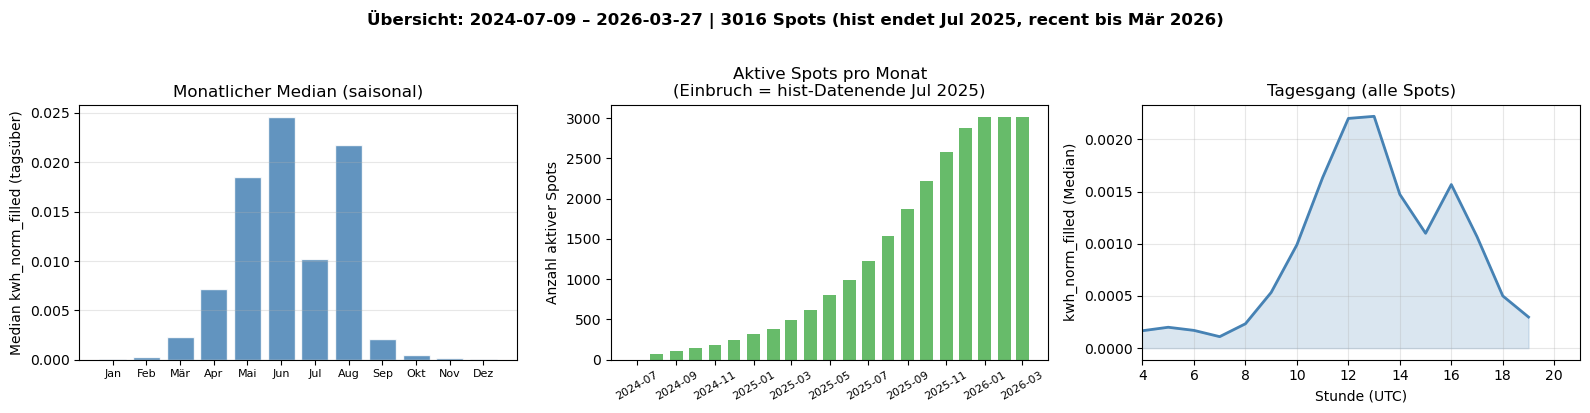

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Monatliche Produktion ──────────────────────────────────────────
ax = axes[0]
monthly = df[df['_daylight']].groupby('_month_num')['kwh_norm_filled'].median()
labels = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
ax.bar(range(1, 13), [monthly.get(m, 0) for m in range(1, 13)],
       color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Median kwh_norm_filled (tagsüber)')
ax.set_title('Monatlicher Median (saisonal)')
ax.grid(True, axis='y', alpha=0.3)

# ── Plot 2: Aktive Spots pro Monat ────────────────────────────────────────
ax = axes[1]
cov = df.groupby(df['ts'].dt.to_period('M'))['spot_uuid'].nunique()
cov.index = cov.index.to_timestamp()
ax.bar(cov.index, cov.values, width=20, color='#4CAF50', alpha=0.85)
ax.set_ylabel('Anzahl aktiver Spots')
ax.set_title('Aktive Spots pro Monat\n(Einbruch = hist-Datenende Jul 2025)')
ax.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 3: Tagesgang (Gesamtdatensatz) ───────────────────────────────────
ax = axes[2]
dl_sample = df[df['_daylight'] & df['kwh_norm_filled'].notna()]
tagesgang = dl_sample.groupby('_hour')['kwh_norm_filled'].median()
ax.plot(tagesgang.index, tagesgang.values, color='steelblue', lw=2)
ax.fill_between(tagesgang.index, tagesgang.values, alpha=0.2, color='steelblue')
ax.set_xlabel('Stunde (UTC)')
ax.set_ylabel('kwh_norm_filled (Median)')
ax.set_title('Tagesgang (alle Spots)')
ax.set_xlim(4, 21)
ax.grid(True, alpha=0.3)

ts_range = f'{df["ts"].min().date()} – {df["ts"].max().date()}'
plt.suptitle(f'Übersicht: {ts_range} | {n_spots} Spots (hist endet Jul 2025, recent bis Mär 2026)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '00_combined_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
kwh_nonzero = df.loc[df['kwh'] > 0, 'kwh']
n_total = len(df)
n_zero  = (df['kwh'] == 0).sum()
n_nan   = df['kwh'].isna().sum()

print('=== kwh Statistik (nur Werte > 0) ===')
print(f'  Mean:   {kwh_nonzero.mean():.4f} kWh')
print(f'  Median: {kwh_nonzero.median():.4f} kWh')
print(f'  Std:    {kwh_nonzero.std():.4f} kWh')
print(f'\n=== Nullwerte & NaN ===')
print(f'  kwh = 0:  {n_zero:,} ({n_zero/n_total*100:.2f}%)')
print(f'  kwh NaN:  {n_nan:,} ({n_nan/n_total*100:.2f}%)  ← fehlende Messungen (Pipeline-NaN)')

=== kwh Statistik (nur Werte > 0) ===
  Mean:   0.2000 kWh
  Median: 0.0024 kWh
  Std:    2.3689 kWh

=== Nullwerte & NaN ===
  kwh = 0:  28,400,189 (41.82%)
  kwh NaN:  3,297,136 (4.85%)  ← fehlende Messungen (Pipeline-NaN)


In [7]:
_ts_agg      = df.groupby('spot_uuid', observed=True)['ts'].agg(['min', 'max'])
_active_days = (_ts_agg['max'] - _ts_agg['min']).dt.total_seconds() / 86400

_day_mask = df['_hour'].between(6, 20)

# Alles direkt ohne _day Variable
_pct_nan = (df.loc[_day_mask, ['spot_uuid', 'kwh_norm']]
              .assign(_is_nan=df.loc[_day_mask, 'kwh_norm'].isna())
              .groupby('spot_uuid', observed=True)['_is_nan']
              .mean().mul(100).round(2))
gc.collect()

_pct_zero = (df.loc[_day_mask, ['spot_uuid', 'kwh_norm_filled']]
               .assign(_is_zero=(df.loc[_day_mask, 'kwh_norm_filled'] == 0))
               .groupby('spot_uuid', observed=True)['_is_zero']
               .mean().mul(100).round(2))
gc.collect()

_kwh_median = (df.loc[_day_mask & (df['kwh_norm_filled'] > 0), ['spot_uuid', 'kwh_norm_filled']]
                 .groupby('spot_uuid', observed=True)['kwh_norm_filled']
                 .median().round(4))
gc.collect()

del _day_mask; gc.collect()

spot_summary = pd.DataFrame({
    'spot_uuid':       _ts_agg.index,
    'active_start':    _ts_agg['min'].dt.date.values,
    'active_end':      _ts_agg['max'].dt.date.values,
    'active_days':     _active_days.values,
    'pct_nan_day':     _pct_nan.reindex(_ts_agg.index).values,
    'pct_zero_day':    _pct_zero.reindex(_ts_agg.index).values,
    'kwh_norm_median': _kwh_median.reindex(_ts_agg.index).fillna(0).values,
}).sort_values('pct_nan_day').reset_index(drop=True)

del _ts_agg, _active_days, _pct_nan, _pct_zero, _kwh_median; gc.collect()

per_spot_miss = spot_summary.set_index('spot_uuid')['pct_nan_day']
spot_summary.to_csv(OUTPUT_DIR / 'spot_summary.csv', index=False)
print(f'Spot-Tabelle: {len(spot_summary)} Spots')
print(f'\nNaN-Rate kwh_norm tagsüber (= echte Messlücken):')
print(f'  Median: {spot_summary["pct_nan_day"].median():.1f}%')
print(f'  >10% NaN: {(spot_summary["pct_nan_day"] > 10).sum()} Spots')
spot_summary.head(10)

Spot-Tabelle: 3016 Spots

NaN-Rate kwh_norm tagsüber (= echte Messlücken):
  Median: 7.0%
  >10% NaN: 1038 Spots


,spot_uuid,active_start,active_end,active_days,pct_nan_day,pct_zero_day,kwh_norm_median
0,f173b1f3-8d19-5912-b9af-68fbfe98aedf,2025-09-07,2026-03-27,200.500000,0.05,1.83,0.0015
1,0485760e-f939-5d23-a09a-7763d7bfee1a,2025-03-30,2026-03-27,361.500000,0.07,0.39,0.0131
2,7ffcd3f3-1a4f-531a-a63c-fd0b63a645da,2025-01-26,2026-03-26,423.989583,0.12,0.40,0.0009
3,f6e1690e-82bd-5367-a51e-7bb1724408ed,2024-08-18,2026-03-27,585.500000,0.12,2.34,0.0094
4,5396a548-6233-5739-afb9-7644fe787c8c,2024-09-19,2026-03-27,553.489583,0.24,4.48,0.0020
5,baf0f3b3-120f-5e13-b574-f8646ad754c7,2025-10-28,2026-03-26,149.489583,0.26,1.45,0.0012
6,4e2edf49-ebbd-5a7c-9f32-e7b6e4e79ae3,2025-05-27,2026-03-27,303.500000,0.27,5.47,0.0012
7,731ad75e-8dd8-5f30-b683-06b64815668f,2025-09-14,2026-03-27,193.500000,0.27,1.61,0.0006
8,f7c60f96-ffa2-53f2-bb80-9509de578b41,2024-10-28,2026-03-26,513.989583,0.30,4.44,0.0406
9,a4fdc743-8327-57fd-8c45-1e4bf692ec95,2025-10-07,2026-03-27,170.500000,0.32,17.94,0.0017


## 1. Datensatz-Übersicht & Vollständigkeit

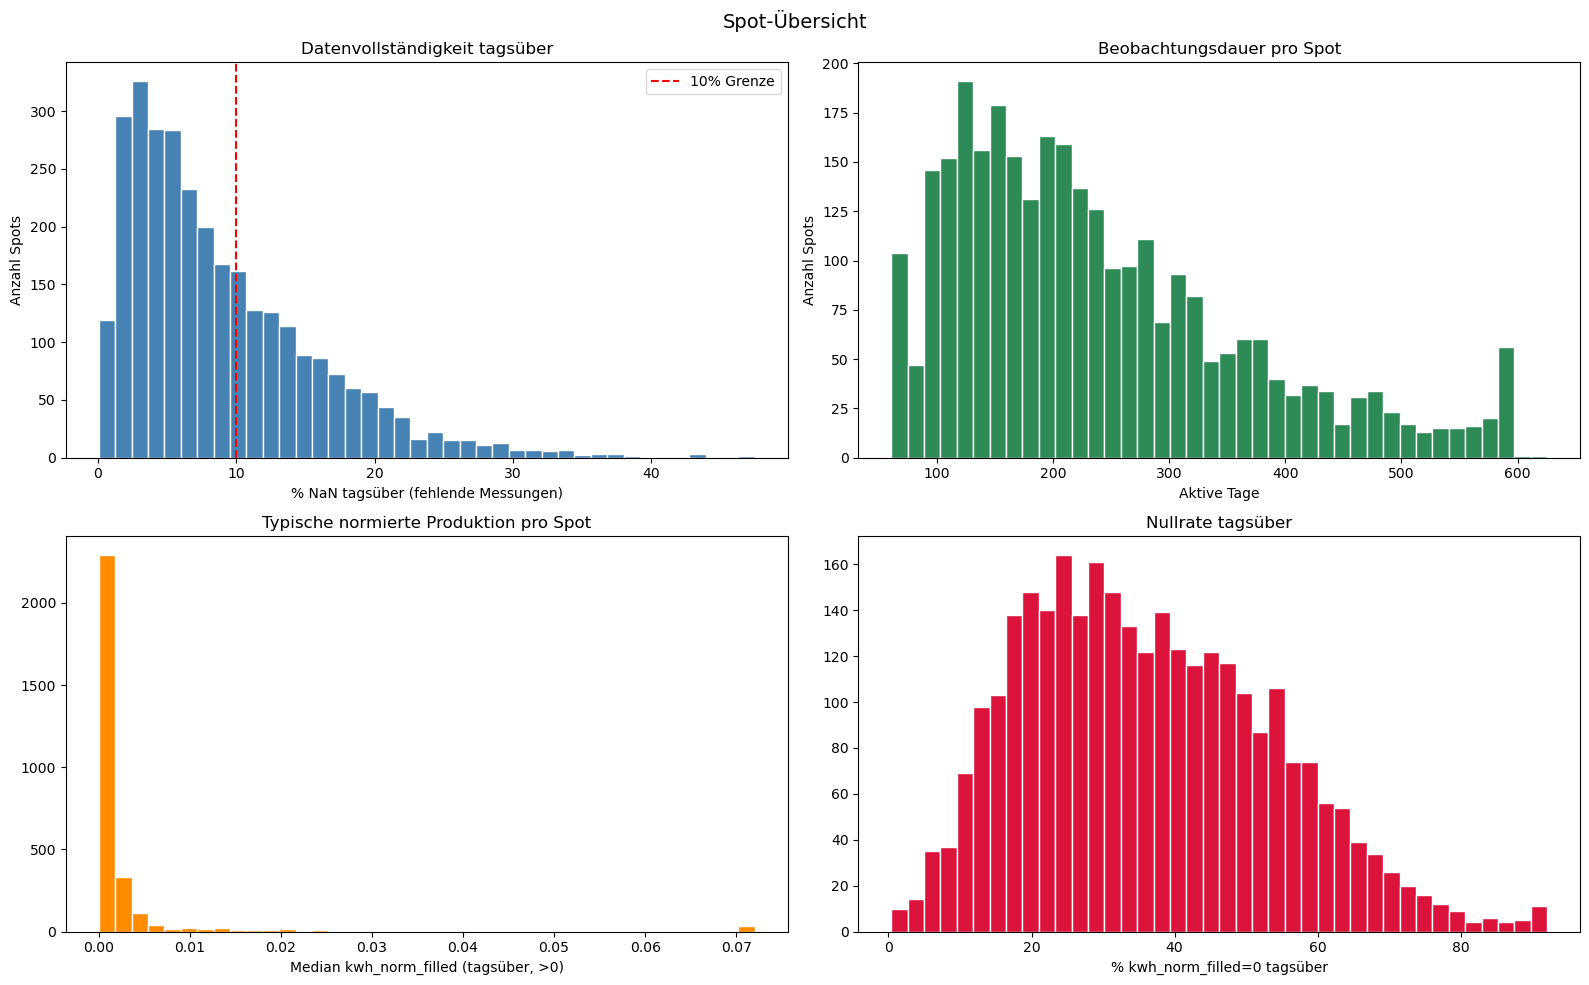

Spots nach NaN-Bucket (echte Messlücken):
pct_nan_day
<5%       1077
5–10%      901
10–25%     944
25–50%      94
>50%         0


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Spot-Übersicht', fontsize=14)

ax = axes[0, 0]
ax.hist(spot_summary['pct_nan_day'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(10, color='red', ls='--', lw=1.5, label='10% Grenze')
ax.set_xlabel('% NaN tagsüber (fehlende Messungen)')
ax.set_ylabel('Anzahl Spots')
ax.set_title('Datenvollständigkeit tagsüber')
ax.legend()

ax = axes[0, 1]
ax.hist(spot_summary['active_days'], bins=40, color='seagreen', edgecolor='white')
ax.set_xlabel('Aktive Tage')
ax.set_ylabel('Anzahl Spots')
ax.set_title('Beobachtungsdauer pro Spot')

ax = axes[1, 0]
kwh_med_clip = spot_summary['kwh_norm_median'].clip(upper=spot_summary['kwh_norm_median'].quantile(0.99))
ax.hist(kwh_med_clip, bins=40, color='darkorange', edgecolor='white')
ax.set_xlabel('Median kwh_norm_filled (tagsüber, >0)')
ax.set_title('Typische normierte Produktion pro Spot')

ax = axes[1, 1]
ax.hist(spot_summary['pct_zero_day'], bins=40, color='crimson', edgecolor='white')
ax.set_xlabel('% kwh_norm_filled=0 tagsüber')
ax.set_title('Nullrate tagsüber')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_spot_overview.png', dpi=100)
plt.show()

buckets = pd.cut(spot_summary['pct_nan_day'], bins=[0,5,10,25,50,100],
                 labels=['<5%','5–10%','10–25%','25–50%','>50%'])
print('Spots nach NaN-Bucket (echte Messlücken):')
print(buckets.value_counts().sort_index().to_string())


## 1b. Werte um Null/NaN – sind Ausreißer isoliert oder strukturell?

Für jeden NaN oder 0-kWh Wert (tagsüber, solar_elevation>5) schauen wir:
ob die direkten Nachbarn (±4 Slots = ±1h) im Median ebenfalls niedrig sind (→ strukturell)
oder ob sie hoch sind (→ isolierter Ausfall/Messlücke).


In [9]:
_dl = df[df['solar_elevation'] > 5][['spot_uuid', 'ts', 'kwh_norm']].copy()
_dl = _dl.sort_values(['spot_uuid', 'ts']).reset_index(drop=True)

WINDOW = 4
results = []

for label, mask in [('NaN', _dl['kwh_norm'].isna()), ('Zero', _dl['kwh_norm'] == 0)]:
    if mask.sum() == 0:
        continue

    # Nur ersten 5000 nehmen
    idxs = _dl[mask].index[:5000]

    # Vektorisiert: für jeden Index alle Nachbarn auf einmal
    neighbor_rows = []
    for offset in range(-WINDOW, WINDOW + 1):
        shifted_idx = (idxs.to_numpy() + offset).clip(0, len(_dl) - 1)
        neighbor_rows.append(
            _dl.iloc[shifted_idx][['spot_uuid', 'kwh_norm']].assign(center_idx=idxs.values)
        )

    nbdf_all = pd.concat(neighbor_rows, ignore_index=True)

    # Nur gleicher Spot
    center_spots = _dl.loc[idxs, 'spot_uuid'].values
    center_spot_map = dict(zip(idxs, center_spots))
    nbdf_all = nbdf_all[nbdf_all['spot_uuid'] == nbdf_all['center_idx'].map(center_spot_map)]

    # Statistiken pro center_idx
    stats = nbdf_all.groupby('center_idx')['kwh_norm'].agg(
        pct_zero=lambda x: (x == 0).mean(),
        pct_nan=lambda x: x.isna().mean(),
    )

    combined = stats['pct_zero'] + stats['pct_nan']
    results.append({
        'type':           label,
        'n':              int(mask.sum()),
        'isolated_pct':   float((combined < 0.5).mean() * 100),
        'structural_pct': float((combined >= 0.5).mean() * 100),
    })
    del nbdf_all, stats, combined; gc.collect()

del _dl; gc.collect()

if results:
    print('Analyse NaN/0 tagsüber:')
    for r in results:
        print(f'  {r["type"]:4s}: {r["n"]:>8,} | isoliert: {r["isolated_pct"]:.1f}% | strukturell: {r["structural_pct"]:.1f}%')
else:
    print('Keine NaN/0-Werte tagsüber gefunden.')

Analyse NaN/0 tagsüber:
  NaN : 2,663,664 | isoliert: 1.6% | strukturell: 98.4%
  Zero: 3,474,355 | isoliert: 13.2% | strukturell: 86.8%


## 2. Verteilungen (kWh-Tagesgang & Histogramm)

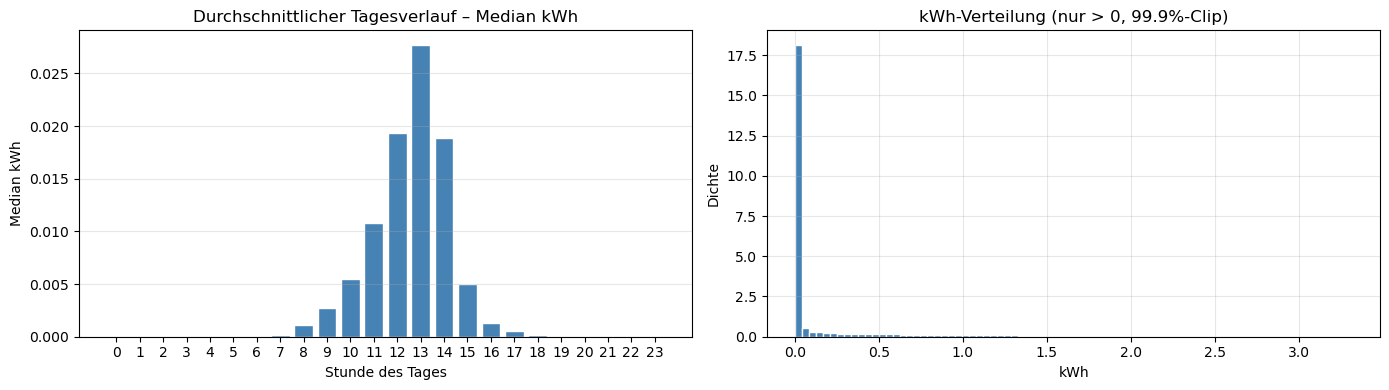

In [10]:
df['_hour'] = df['ts'].dt.hour
hourly = df.groupby('_hour')['kwh'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Stunde des Tages')
ax.set_ylabel('Median kWh')
ax.set_title('Durchschnittlicher Tagesverlauf – Median kWh')
ax.set_xticks(range(0, 24))
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.hist(df.loc[df['kwh'] > 0, 'kwh'].clip(upper=df['kwh'].quantile(0.999)),
        bins=80, color='steelblue', edgecolor='white', density=True)
ax.set_xlabel('kWh')
ax.set_ylabel('Dichte')
ax.set_title('kWh-Verteilung (nur > 0, 99.9%-Clip)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_distributions.png', dpi=100)
plt.show()

## 3. Saisonalität

Monatliche Medianproduktion (Zeitreihe) und Heatmap Stunde × Monat — zeigt die saisonale Abhängigkeit der PV-Erzeugung.

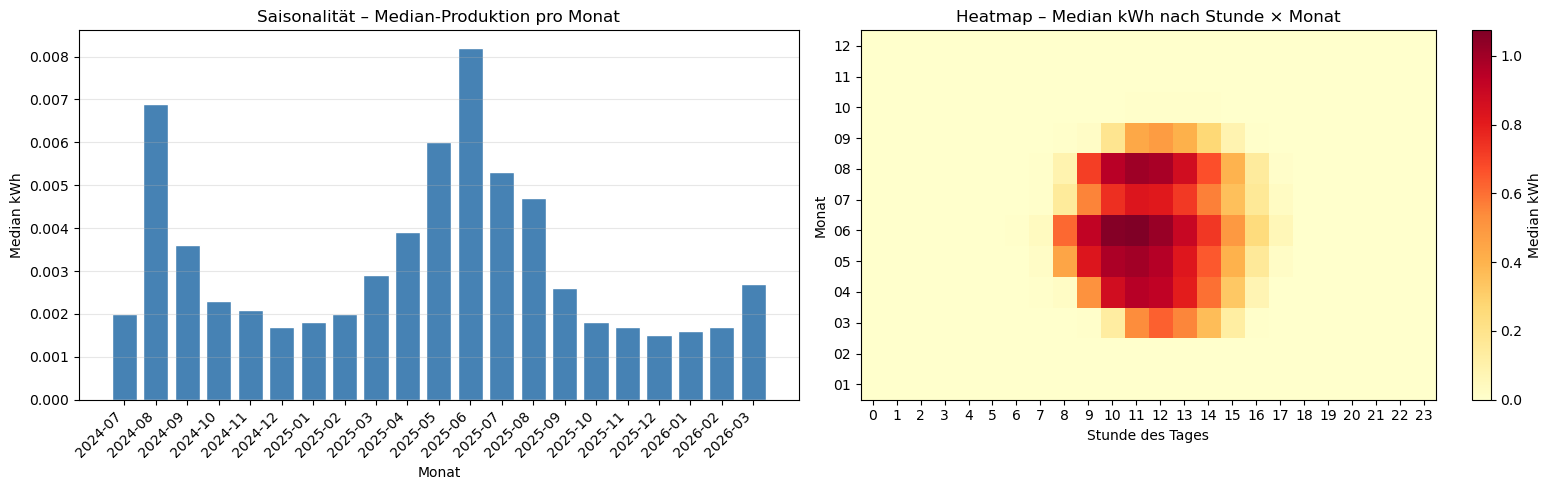

24

In [12]:
# ── Plot 1: Saisonalität ──────────────────────────────────────────────
monthly = (df.loc[df['kwh'] > 0, ['_month', 'kwh']]
             .groupby('_month')['kwh'].median()
             .sort_index())

# ── Plot 2: Heatmap ───────────────────────────────────────────────────
heatmap_data = (df.loc[:, ['_month_num', '_hour', 'kwh']]
                  .groupby(['_month_num', '_hour'])['kwh']
                  .median()
                  .unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x_labels = [str(x) for x in monthly.index]   # ← als String
ax.bar(range(len(monthly)), monthly.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_xlabel('Monat')
ax.set_ylabel('Median kWh')
ax.set_title('Saisonalität – Median-Produktion pro Monat')
ax.grid(True, axis='y', alpha=0.3)
del monthly, x_labels; gc.collect()

ax = axes[1]
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f'{m:02d}' for m in heatmap_data.index])
ax.set_xlabel('Stunde des Tages'); ax.set_ylabel('Monat')
ax.set_title('Heatmap – Median kWh nach Stunde × Monat')
plt.colorbar(im, ax=ax, label='Median kWh')
del heatmap_data; gc.collect()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_seasonality.png', dpi=100)
plt.show()
gc.collect()

## 4. Strahlungs- & Wetteranalyse

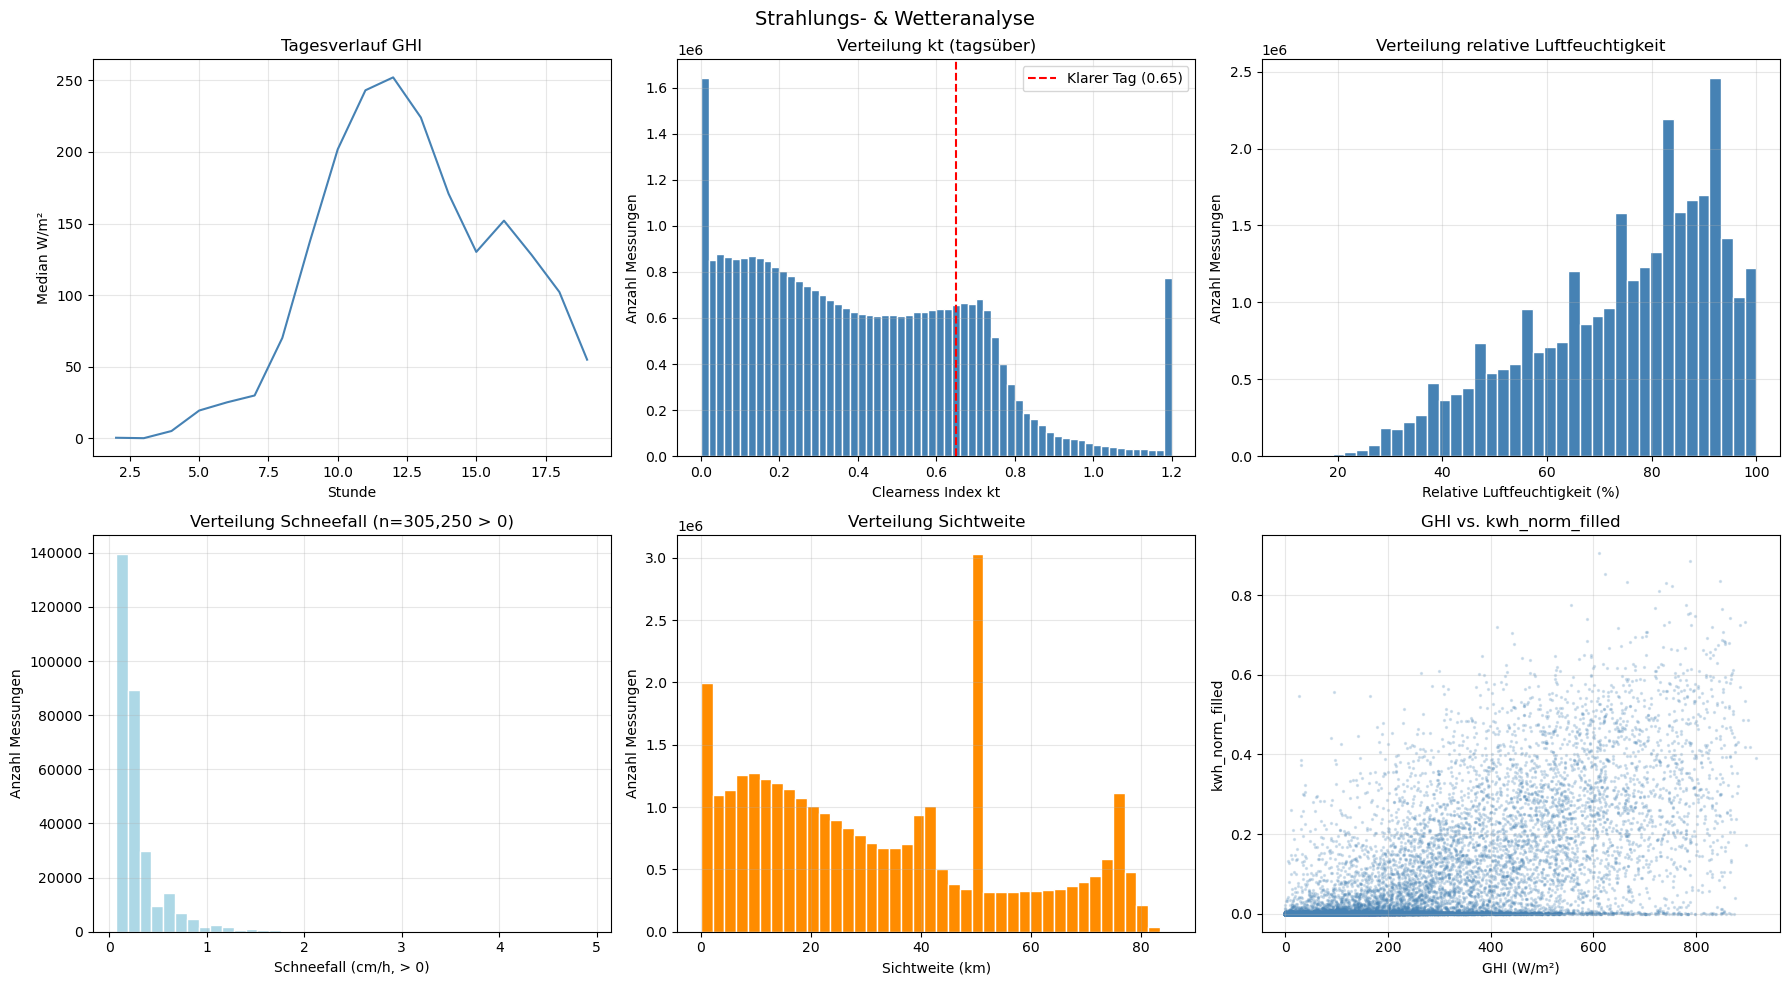

In [5]:
_daylight = df['_daylight']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Strahlungs- & Wetteranalyse', fontsize=14)

# 1. GHI-Tagesverlauf ← hier war das Problem
ax = axes[0, 0]
ax.plot(df.loc[_daylight, ['_hour', 'ghi']].groupby('_hour')['ghi'].median(),
        color='steelblue')
ax.set_xlabel('Stunde'); ax.set_ylabel('Median W/m²')
ax.set_title('Tagesverlauf GHI')
ax.grid(True, alpha=0.3)

# 2. kt-Verteilung
ax = axes[0, 1]
kt_day = df.loc[_daylight, 'kt'].dropna().clip(0, 1.5)
ax.hist(kt_day, bins=60, color='steelblue', edgecolor='white')
ax.axvline(0.65, color='red', ls='--', lw=1.5, label='Klarer Tag (0.65)')
ax.set_xlabel('Clearness Index kt')
ax.set_ylabel('Anzahl Messungen')
ax.set_title('Verteilung kt (tagsüber)')
ax.legend(); ax.grid(True, alpha=0.3)
del kt_day; gc.collect()

# 3. relative_humidity_2m
ax = axes[0, 2]
if 'relative_humidity_2m' in df.columns:
    ax.hist(df.loc[_daylight, 'relative_humidity_2m'].dropna(), bins=40,
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Relative Luftfeuchtigkeit (%)')
    ax.set_ylabel('Anzahl Messungen')
    ax.set_title('Verteilung relative Luftfeuchtigkeit')
    ax.grid(True, alpha=0.3)

# 4. snowfall
ax = axes[1, 0]
if 'snowfall' in df.columns:
    snow_pos = df.loc[_daylight, 'snowfall'].dropna()
    snow_pos = snow_pos[snow_pos > 0]
    ax.hist(snow_pos, bins=40, color='lightblue', edgecolor='white')
    ax.set_xlabel('Schneefall (cm/h, > 0)')
    ax.set_ylabel('Anzahl Messungen')
    ax.set_title(f'Verteilung Schneefall (n={len(snow_pos):,} > 0)')
    ax.grid(True, alpha=0.3)
    del snow_pos; gc.collect()

# 5. visibility
ax = axes[1, 1]
if 'visibility' in df.columns:
    ax.hist(df.loc[_daylight, 'visibility'].dropna() / 1000, bins=40,
            color='darkorange', edgecolor='white')
    ax.set_xlabel('Sichtweite (km)')
    ax.set_ylabel('Anzahl Messungen')
    ax.set_title('Verteilung Sichtweite')
    ax.grid(True, alpha=0.3)

# 6. GHI vs kwh_norm_filled
ax = axes[1, 2]
samp = (df.loc[_daylight, ['ghi', 'kwh_norm_filled']]
          .dropna()
          .sample(min(20000, _daylight.sum()), random_state=42))
ax.scatter(samp['ghi'], samp['kwh_norm_filled'], alpha=0.2, s=2, color='steelblue')
ax.set_xlabel('GHI (W/m²)'); ax.set_ylabel('kwh_norm_filled')
ax.set_title('GHI vs. kwh_norm_filled')
ax.grid(True, alpha=0.3)
del samp; gc.collect()

del _daylight; gc.collect()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_irradiance.png', dpi=100)
plt.show()

## 5. Panel-Neigung & Ausrichtung (Tilt & Azimuth)

Die Tilt/Azimuth-Schätzung basiert auf dem Algorithmus von Meng, Loonen & Hensen (2020),
Solar Energy 211:418-432. Klare Tage pro Monat werden identifiziert und die POA-Einstrahlung
(Perez-Modell) mit dem tatsächlichen PV-Ertrag verglichen.

Panel-Tilt geschätzt: 3016 / 3016 Spots


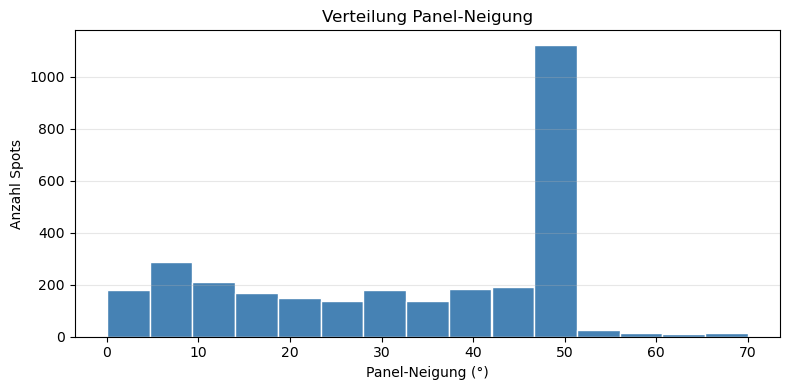

In [6]:
if 'panel_tilt' in df.columns:
    tilt_df = df.groupby('spot_uuid')['panel_tilt'].first().reset_index()
    n_inferred = tilt_df['panel_tilt'].notna().sum()
    print(f'Panel-Tilt geschätzt: {n_inferred} / {len(tilt_df)} Spots')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(tilt_df['panel_tilt'].dropna(), bins=15, color='steelblue', edgecolor='white')
    ax.set_xlabel('Panel-Neigung (°)')
    ax.set_ylabel('Anzahl Spots')
    ax.set_title('Verteilung Panel-Neigung')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '06_tilt_azimuth.png', dpi=100)
    plt.show()

    del tilt_df; gc.collect()
else:
    print('panel_tilt nicht im DataFrame')

## 6. Ausreißeranalyse (Robust Z-Score mit MAD)

Residuen werden pro (Spot, 15-Min-Slot) auf Basis der Median-Baseline berechnet.
Z-Score nach Hampel: `0.6745 * (x - median) / MAD`. Schwellwert |z| > 8, nur tagsüber.

Berechne Baseline (Median pro Spot × Slot)...
Ausreißer gesamt:     6,985,234  (10.285%)
Anomalie-Rate Median: 22.54%

Top 10 Spots:
spot_uuid
8a712422-f661-52aa-aebe-35692d3c3e98    43.70
8937795a-ba25-5939-8ecb-8c3c3685e3cb    41.35
778aea02-4657-5524-bc54-8a5481fe177f    41.26
1529e213-cb45-5f98-96fb-0ba3bc142dc9    40.42
67ad5778-647d-56dd-be0e-79f96ef6c666    39.94
183cd86b-f963-5d16-a59f-ce74a3e277ca    39.90
9764a5d6-7aca-5d1d-b840-07cdaf3f7bfa    39.83
aad3b8b2-0628-5349-9b86-d1311c755a48    39.79
99dfdace-cbc3-5a35-9d3f-496bb1653ec1    39.63
18182bd2-d080-512d-8385-3a55d10204cc    39.54


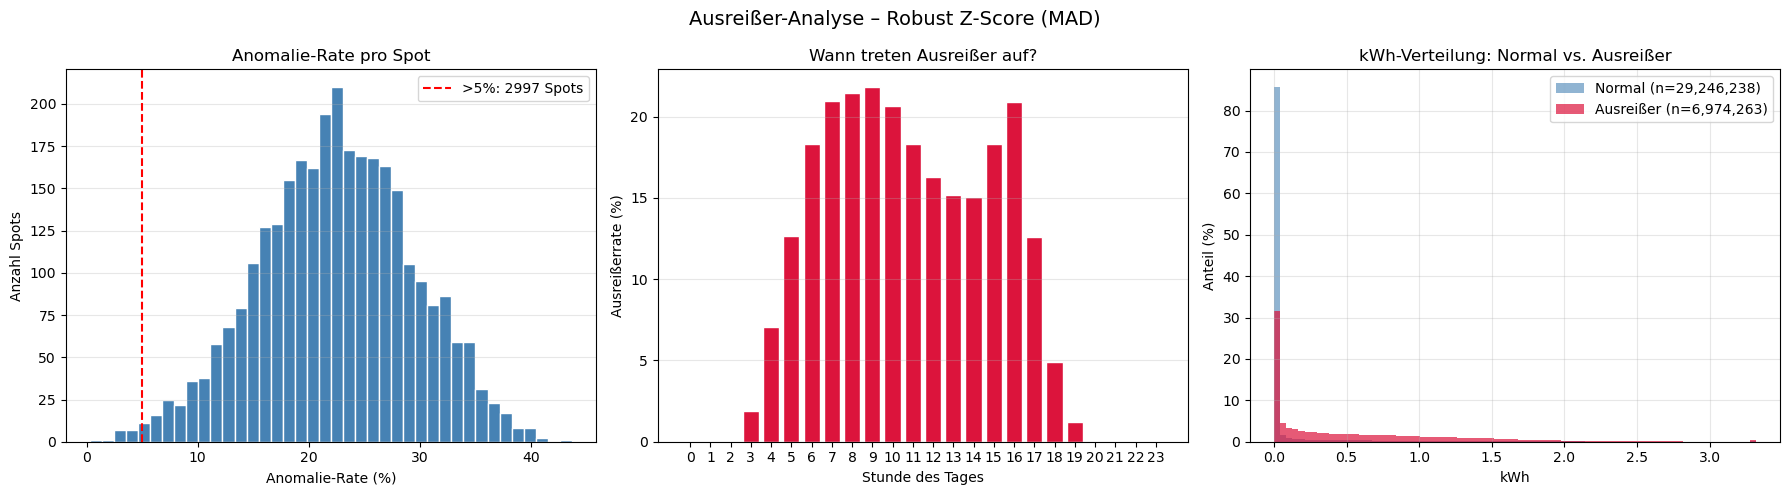

0

In [7]:
Z_THR = 8.0
df['_tod_slot'] = (df['ts'].dt.hour * 4 + df['ts'].dt.minute // 15).astype('int16')

print('Berechne Baseline (Median pro Spot × Slot)...')
slot_stats = (df.groupby(['spot_uuid', '_tod_slot'], observed=True)['kwh']
                .agg(slot_median='median',
                     slot_mad=lambda x: (x - x.median()).abs().median())
                .reset_index()
                .set_index(['spot_uuid', '_tod_slot']))

# Direkt mappen statt merge → kein RAM-Spike
_idx        = pd.MultiIndex.from_arrays([df['spot_uuid'], df['_tod_slot']])
slot_median = slot_stats['slot_median'].reindex(_idx).values
slot_mad    = slot_stats['slot_mad'].reindex(_idx).values
del slot_stats, _idx; gc.collect()

resid   = df['kwh'].fillna(0).values - np.nan_to_num(slot_median)
z_score = 0.6745 * resid / (np.nan_to_num(slot_mad) + 1e-6)
del slot_median, slot_mad, resid; gc.collect()

df['is_outlier'] = (np.abs(z_score) > Z_THR) & df['_daylight']
del z_score; gc.collect()

anomaly_rates = (
    df[df['_daylight']]
      .groupby('spot_uuid', observed=True)['is_outlier']
      .mean()
      .sort_values(ascending=False)
)

print(f'Ausreißer gesamt:     {df["is_outlier"].sum():,}  ({df["is_outlier"].mean()*100:.3f}%)')
print(f'Anomalie-Rate Median: {anomaly_rates.median()*100:.2f}%')
print(f'\nTop 10 Spots:')
print((anomaly_rates.head(10) * 100).round(2).to_string())

outlier_report = anomaly_rates.reset_index().rename(columns={'is_outlier': 'anomaly_rate'})
outlier_report['n_outliers'] = (
    df[df['_daylight']].groupby('spot_uuid', observed=True)['is_outlier'].sum()
      .reindex(outlier_report['spot_uuid']).values
)
outlier_report.to_csv(OUTPUT_DIR / 'outlier_report.csv', index=False)

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ausreißer-Analyse – Robust Z-Score (MAD)', fontsize=14)

ax = axes[0]
rates  = outlier_report['anomaly_rate'] * 100
n_high = (rates > 5.0).sum()
ax.hist(rates, bins=40, color='steelblue', edgecolor='white')
ax.axvline(5.0, color='red', ls='--', lw=1.5, label=f'>5%: {n_high} Spots')
ax.set_xlabel('Anomalie-Rate (%)'); ax.set_ylabel('Anzahl Spots')
ax.set_title('Anomalie-Rate pro Spot')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
out_h   = df.loc[df['is_outlier'], '_hour'].value_counts().sort_index()
total_h = df['_hour'].value_counts().sort_index()
rate_h  = (out_h / total_h * 100).fillna(0)
ax.bar(rate_h.index, rate_h.values, color='crimson', edgecolor='white')
ax.set_xlabel('Stunde des Tages'); ax.set_ylabel('Ausreißerrate (%)')
ax.set_title('Wann treten Ausreißer auf?')
ax.set_xticks(range(0, 24)); ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
clip_val = df['kwh'].quantile(0.999)
bins     = np.linspace(0, clip_val, 80)

# Nacheinander berechnen um RAM zu sparen
clean_kwh       = df.loc[~df['is_outlier'] & (df['kwh'] > 0), 'kwh'].clip(upper=clip_val)
n_clean         = len(clean_kwh)
counts_c, edges = np.histogram(clean_kwh, bins=bins)
del clean_kwh; gc.collect()

out_kwh         = df.loc[df['is_outlier'] & (df['kwh'] > 0), 'kwh'].clip(upper=clip_val)
n_out           = len(out_kwh)
counts_o, _     = np.histogram(out_kwh, bins=bins)
del out_kwh; gc.collect()

widths = np.diff(edges)
ax.bar(edges[:-1], counts_c / counts_c.sum() * 100, width=widths,
       alpha=0.6, color='steelblue', label=f'Normal (n={n_clean:,})', align='edge')
ax.bar(edges[:-1], counts_o / counts_o.sum() * 100, width=widths,
       alpha=0.7, color='crimson',   label=f'Ausreißer (n={n_out:,})', align='edge')
ax.set_xlabel('kWh'); ax.set_ylabel('Anteil (%)')
ax.set_title('kWh-Verteilung: Normal vs. Ausreißer')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_outlier.png', dpi=100)
plt.show()

del anomaly_rates, outlier_report, rates, out_h, total_h, rate_h
gc.collect()

## 7. Tagesprofil-Analyse (Klare Tage)

Berechnet pro Spot × Tag: Peak-Zeitpunkt, Morgen/Nachmittag-Ratio und Orientierungs-Proxy (Ost/Süd/West).
Basis: klare Tage mit kt > 0.65. Diese Features ergänzen die Tilt/Azimuth-Schätzung als Validierung.

Klare Tage (kt > 0.65): 4,826,844 Zeilen
orientation_proxy
West    2204
Süd      562
Ost      247


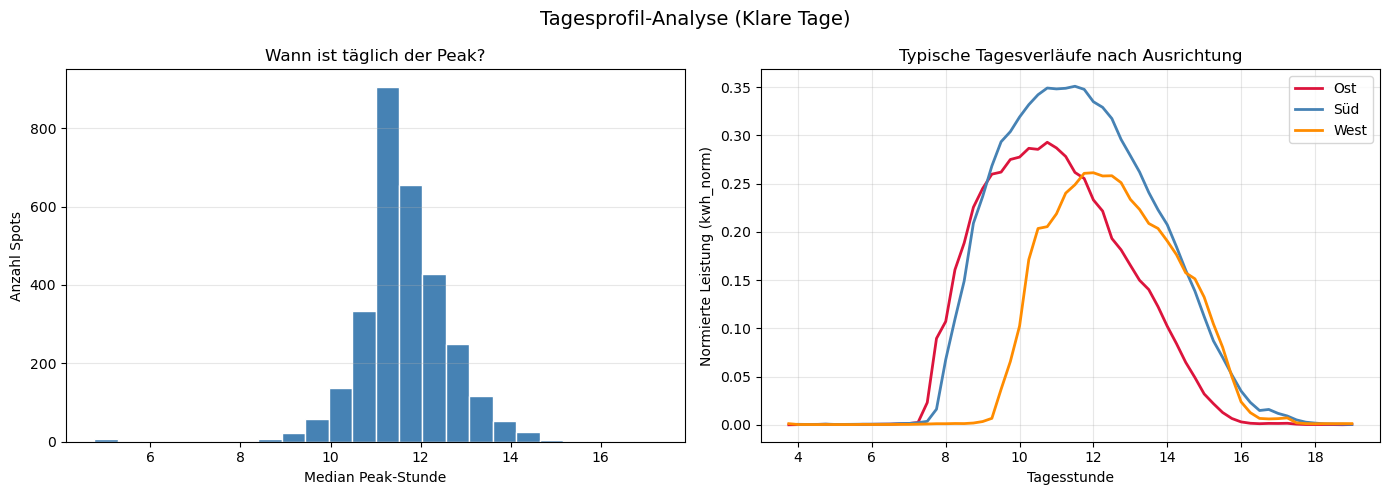

22039

In [10]:
# ── Daylight ohne copy ────────────────────────────────────────────────
_dl_mask = df['solar_elevation'] > 5
dl_df = df.loc[_dl_mask, ['spot_uuid', 'ts', 'kt', 'kwh', 'kwh_norm', 'solar_elevation']].copy()
del _dl_mask; gc.collect()

dl_df['_date']     = dl_df['ts'].dt.date
dl_df['_hour_dec'] = dl_df['ts'].dt.hour + dl_df['ts'].dt.minute / 60

# ── Klare Tage ────────────────────────────────────────────────────────
if 'kt' in dl_df.columns:
    day_kt = (
        dl_df.groupby(['spot_uuid', '_date'], observed=True)['kt']
             .median()
             .reset_index(name='day_kt')
    )
    clear_days = day_kt.loc[day_kt['day_kt'] > 0.65, ['spot_uuid', '_date']]
    del day_kt; gc.collect()
else:
    clear_days = dl_df[['spot_uuid', '_date']].drop_duplicates()

dl_clear = dl_df.merge(clear_days, on=['spot_uuid', '_date'], how='inner')
del dl_df, clear_days; gc.collect()

print(f'Klare Tage (kt > 0.65): {len(dl_clear):,} Zeilen')

# ── Solar Noon ────────────────────────────────────────────────────────
snoon_idx = (
    dl_clear.dropna(subset=['solar_elevation'])
            .groupby(['spot_uuid', '_date'], observed=True)['solar_elevation']
            .idxmax()
            .dropna()
            .astype(int)
)

snoon_rows = (
    dl_clear.loc[snoon_idx, ['spot_uuid', '_date', '_hour_dec']]
            .rename(columns={'_hour_dec': 'solar_noon_hour'})
)

del snoon_idx; gc.collect()

# ── Morgen/Nachmittag ─────────────────────────────────────────────────
df_noon = dl_clear.merge(snoon_rows, on=['spot_uuid', '_date'], how='inner')
del snoon_rows; gc.collect()

morn = (
    df_noon.loc[df_noon['_hour_dec'] < df_noon['solar_noon_hour']]
           .groupby(['spot_uuid', '_date'], observed=True)['kwh']
           .sum()
           .reset_index(name='e_morning')
)

after = (
    df_noon.loc[df_noon['_hour_dec'] >= df_noon['solar_noon_hour']]
           .groupby(['spot_uuid', '_date'], observed=True)['kwh']
           .sum()
           .reset_index(name='e_afternoon')
)

del df_noon; gc.collect()

# Wichtig: nicht .fillna(0) auf dem ganzen DataFrame,
# weil spot_uuid categorical sein kann.
morn_pm = morn.merge(after, on=['spot_uuid', '_date'], how='outer')
morn_pm[['e_morning', 'e_afternoon']] = morn_pm[['e_morning', 'e_afternoon']].fillna(0)

morn_pm['morn_pm_ratio'] = morn_pm['e_morning'] / (morn_pm['e_afternoon'] + 1e-6)

del morn, after; gc.collect()

# ── Peak-Stunde ───────────────────────────────────────────────────────
peak_idx = (
    dl_clear.dropna(subset=['kwh'])
            .groupby(['spot_uuid', '_date'], observed=True)['kwh']
            .idxmax()
            .dropna()
            .astype(int)
)

peak_rows = (
    dl_clear.loc[peak_idx, ['spot_uuid', '_date', '_hour_dec']]
            .rename(columns={'_hour_dec': 'peak_hour'})
)

del peak_idx; gc.collect()

# ── Spot-Profil ───────────────────────────────────────────────────────
spot_profile = (
    morn_pm.groupby('spot_uuid', observed=True)['morn_pm_ratio']
           .median()
           .reset_index(name='morn_pm_ratio_median')
           .merge(
               peak_rows.groupby('spot_uuid', observed=True)['peak_hour']
                        .median()
                        .reset_index(name='peak_hour_median'),
               on='spot_uuid',
               how='inner'
           )
)

del morn_pm, peak_rows; gc.collect()

spot_profile['orientation_proxy'] = np.select(
    [
        spot_profile['morn_pm_ratio_median'] > 1.2,
        spot_profile['morn_pm_ratio_median'] < 0.8
    ],
    ['Ost', 'West'],
    default='Süd'
)

print(spot_profile['orientation_proxy'].value_counts().to_string())

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tagesprofil-Analyse (Klare Tage)', fontsize=14)

ax = axes[0]
ax.hist(
    spot_profile['peak_hour_median'].dropna(),
    bins=24,
    color='steelblue',
    edgecolor='white'
)
ax.set_xlabel('Median Peak-Stunde')
ax.set_ylabel('Anzahl Spots')
ax.set_title('Wann ist täglich der Peak?')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]

colors = {
    'Ost': 'crimson',
    'Süd': 'steelblue',
    'West': 'darkorange'
}

orient_spots = spot_profile.groupby('orientation_proxy')['spot_uuid'].apply(list)

dl_clear['_slot'] = dl_clear['ts'].dt.hour + dl_clear['ts'].dt.minute / 60

for orient, color in colors.items():
    if orient not in orient_spots.index:
        continue

    s_list = orient_spots.loc[orient]

    if len(s_list) == 0:
        continue

    sample = rng.choice(s_list, size=min(30, len(s_list)), replace=False)

    sub = dl_clear.loc[dl_clear['spot_uuid'].isin(sample)]
    profile = sub.groupby('_slot', observed=True)['kwh_norm'].median()

    ax.plot(
        profile.index,
        profile.values,
        color=color,
        lw=2,
        label=orient
    )

ax.set_xlabel('Tagesstunde')
ax.set_ylabel('Normierte Leistung (kwh_norm)')
ax.set_title('Typische Tagesverläufe nach Ausrichtung')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_daily_profiles.png', dpi=100)
plt.show()

del dl_clear, spot_profile, orient_spots
gc.collect()

## 8. Anlagenkapazität (kWp-Schätzung)

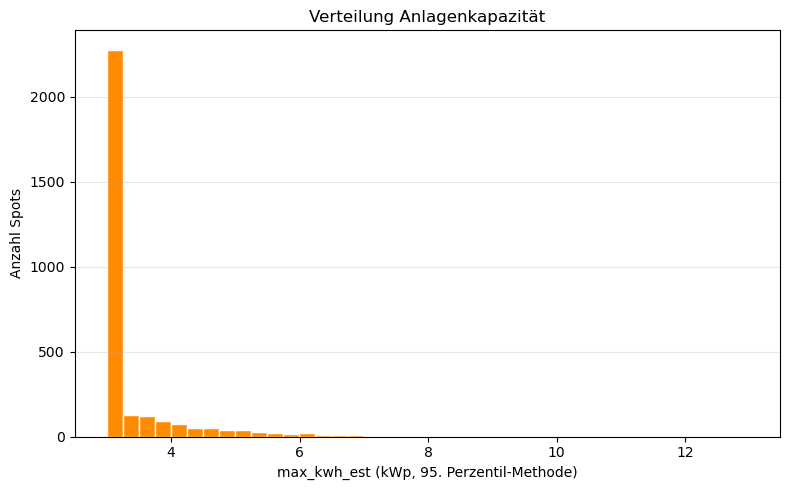

max_kwh_est: min=3.0  median=3.0  max=13.0 kWp


In [11]:
if 'max_kwh_est' in df.columns:
    max_est = df.groupby('spot_uuid')['max_kwh_est'].first().dropna()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(max_est, bins=40, color='darkorange', edgecolor='white')
    ax.set_xlabel('max_kwh_est (kWp, 95. Perzentil-Methode)')
    ax.set_ylabel('Anzahl Spots')
    ax.set_title('Verteilung Anlagenkapazität')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '10_capacity.png', dpi=100)
    plt.show()

    print(f'max_kwh_est: min={max_est.min():.1f}  median={max_est.median():.1f}  max={max_est.max():.1f} kWp')
else:
    print('max_kwh_est nicht vorhanden')


## 9. Analog-Features Analyse

Für jeden Zeitpunkt werden die K=10 ähnlichsten historischen Zeitpunkte derselben Anlage
bestimmt (Suchfenster: ±60 Tage, gewichtete Distanz nach `dni_frac`, `dhi_frac`, `ghi_magnitude`,
Temperatur und Wind). Das Modell erhält vergangene normierte Erzeugungswerte unter
ähnlichen Strahlungsbedingungen als zusätzlichen Kontext.

Analog-Features verfügbar: 67,917,827 / 67,917,827 Zeilen (100.0%)


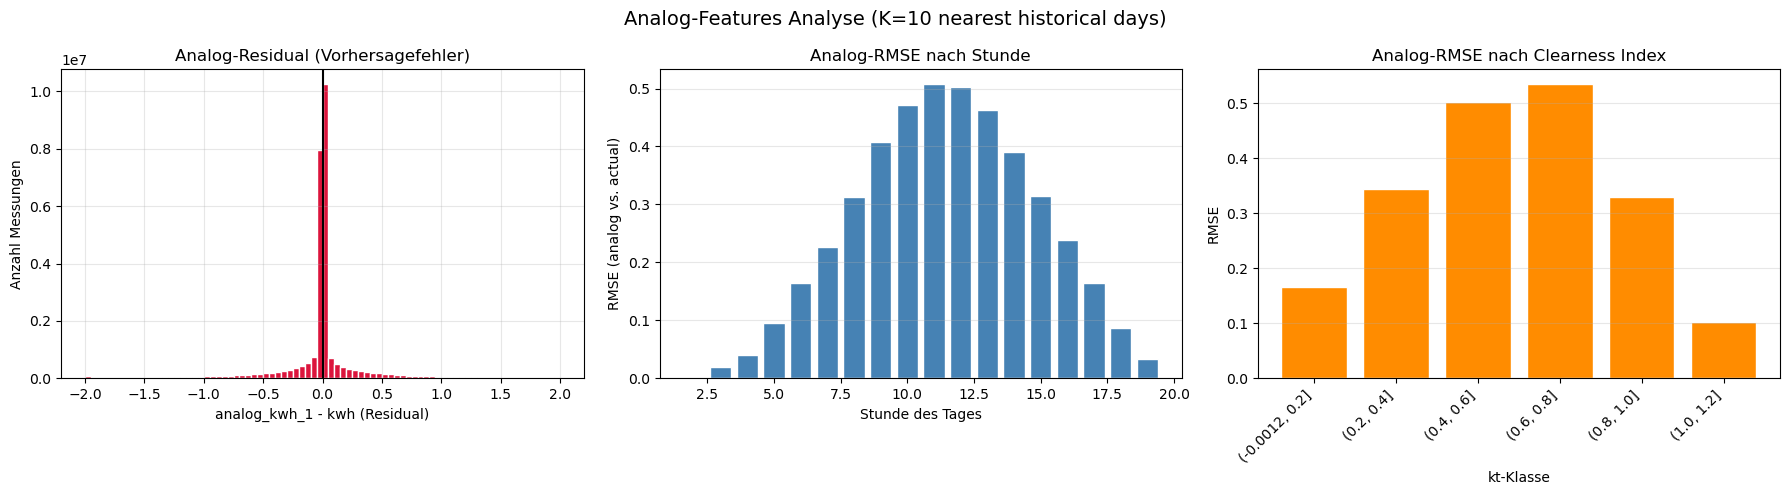

Korrelationen (Spearman, tagsüber):
  analog_kwh_1                  : r = 0.680
  analog_kwh_1_norm             : r = 0.675


In [12]:
if 'analog_kwh_1' in df.columns:
    n_analog = df['analog_kwh_1'].notna().sum()
    print(f'Analog-Features verfügbar: {n_analog:,} / {len(df):,} Zeilen ({n_analog/len(df)*100:.1f}%)')

    # Nur nötige Spalten laden statt copy() auf vollem df
    _mask = df['_daylight'] & df['analog_kwh_1'].notna()
    dl_analog = df.loc[_mask, ['spot_uuid', '_hour', 'kwh', 'kwh_norm',
                                'analog_kwh_1', 'analog_kwh_1_norm', 'kt']].copy()
    del _mask; gc.collect()

    dl_analog['analog_residual'] = dl_analog['analog_kwh_1'] - dl_analog['kwh']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Analog-Features Analyse (K=10 nearest historical days)', fontsize=14)

    ax = axes[0]
    ax.hist(dl_analog['analog_residual'].clip(-2, 2), bins=80,
            color='crimson', edgecolor='white')
    ax.axvline(0, color='black', lw=1.5)
    ax.set_xlabel('analog_kwh_1 - kwh (Residual)')
    ax.set_ylabel('Anzahl Messungen')
    ax.set_title('Analog-Residual (Vorhersagefehler)')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    hourly_rmse = (dl_analog.groupby('_hour')
                             .apply(lambda g: np.sqrt(((g['analog_kwh_1'] - g['kwh'])**2).mean())))
    ax.bar(hourly_rmse.index, hourly_rmse.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Stunde des Tages')
    ax.set_ylabel('RMSE (analog vs. actual)')
    ax.set_title('Analog-RMSE nach Stunde')
    ax.grid(True, axis='y', alpha=0.3)
    del hourly_rmse; gc.collect()

    ax = axes[2]
    if 'kt' in dl_analog.columns:
        dl_analog['kt_bin'] = pd.cut(dl_analog['kt'].clip(0, 1.2), bins=6)
        kt_rmse = (dl_analog.groupby('kt_bin', observed=True)
                             .apply(lambda g: np.sqrt(((g['analog_kwh_1'] - g['kwh'])**2).mean())))
        ax.bar(range(len(kt_rmse)), kt_rmse.values, color='darkorange', edgecolor='white')
        ax.set_xticks(range(len(kt_rmse)))
        ax.set_xticklabels([str(i) for i in kt_rmse.index], rotation=45, ha='right')
        ax.set_xlabel('kt-Klasse')
        ax.set_ylabel('RMSE')
        ax.set_title('Analog-RMSE nach Clearness Index')
        ax.grid(True, axis='y', alpha=0.3)
        del kt_rmse; gc.collect()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '11_analog.png', dpi=100)
    plt.show()

    print('Korrelationen (Spearman, tagsüber):')
    for col in ['analog_kwh_1', 'analog_kwh_1_norm']:
        if col in dl_analog.columns:
            r, _ = spearmanr(dl_analog[col].fillna(0), dl_analog['kwh'].fillna(0))
            print(f'  {col:30s}: r = {r:.3f}')

    del dl_analog; gc.collect()

else:
    print('analog_kwh_1 nicht vorhanden – Analog-Analyse übersprungen')

## 10. Korrelationsanalyse (Spearman)

In [4]:
# Schnell-Test mit einer Spalte
from scipy.stats import rankdata
test_col = 'ghi'
day_mask_np = df['_daylight'].to_numpy(dtype=bool)
x_test = df.loc[day_mask_np, test_col].to_numpy(dtype=np.float64)
y_test = df.loc[day_mask_np, 'kwh_norm_filled'].to_numpy(dtype=np.float64)
valid = np.isfinite(x_test) & np.isfinite(y_test)
xr = rankdata(x_test[valid]).astype(np.float64); xr -= xr.mean()
yr = rankdata(y_test[valid]).astype(np.float64); yr -= yr.mean()
denom = np.sqrt(np.dot(xr, xr) * np.dot(yr, yr))
print(f"r = {np.dot(xr, yr) / denom:.4f}")  # Sollte eine echte Zahl sein

r = 0.6511


Features: 53 | Fehlend: []
Daylight-Zeilen: 30,750,473
Berechne ghi ...
  Spearman r = 0.6511 | n=30,750,473
Berechne dhi ...
  Spearman r = 0.5763 | n=30,750,473
Berechne dni ...
  Spearman r = 0.5698 | n=30,750,473
Berechne tsi ...
  Spearman r = 0.6385 | n=30,750,473
Berechne kt ...
  Spearman r = 0.4881 | n=30,750,473
Berechne dni_frac ...
  Spearman r = 0.3430 | n=30,750,473
Berechne dhi_frac ...
  Spearman r = -0.3735 | n=30,750,473
Berechne ghi_magnitude ...
  Spearman r = 0.6511 | n=30,750,473
Berechne solar_elevation ...
  Spearman r = 0.5439 | n=30,750,473
Berechne solar_azimuth ...
  Spearman r = 0.2090 | n=30,750,473
Berechne temperature_2m ...
  Spearman r = 0.4951 | n=30,750,473
Berechne wind_speed_10m ...
  Spearman r = 0.0504 | n=30,750,473
Berechne precipitation_mm ...
  Spearman r = -0.1718 | n=30,750,473
Berechne relative_humidity_2m ...
  Spearman r = -0.5494 | n=30,750,473
Berechne snowfall ...
  Spearman r = -0.1036 | n=30,750,473
Berechne visibility ...
  Spearma

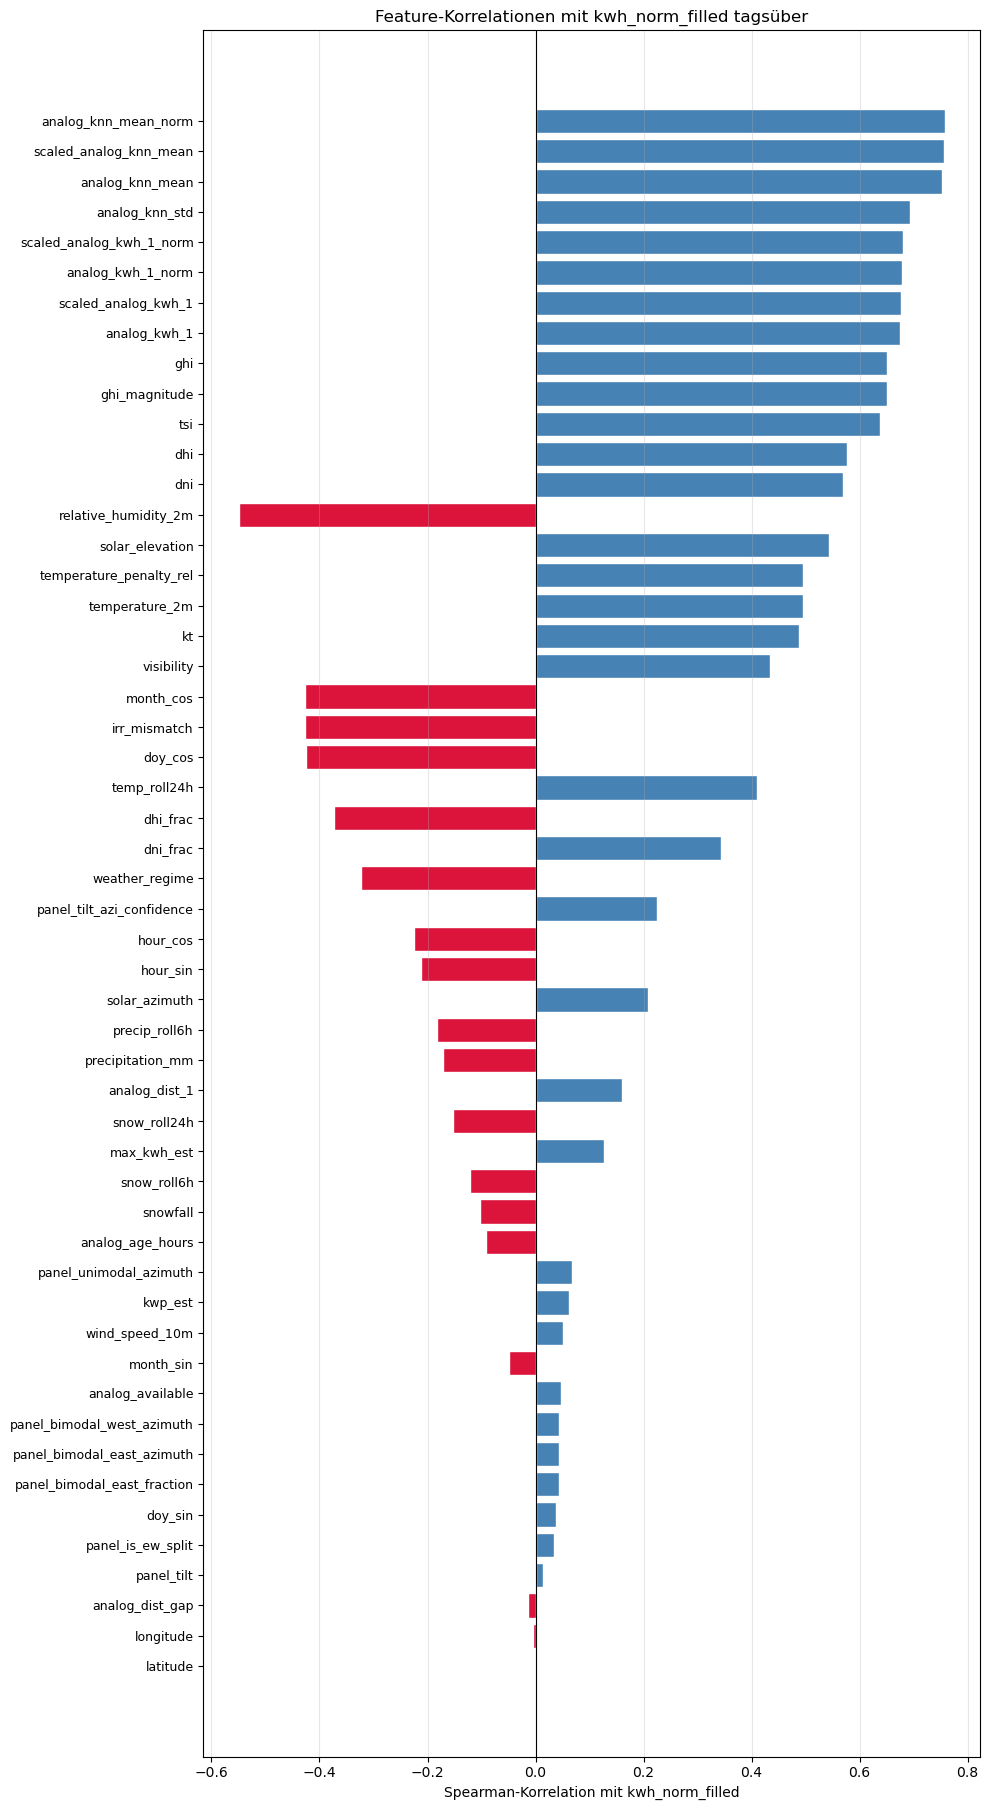


Top 10 Korrelationen Spearman:
analog_knn_mean_norm        0.758
scaled_analog_knn_mean      0.756
analog_knn_mean             0.752
analog_knn_std              0.694
scaled_analog_kwh_1_norm    0.680
analog_kwh_1_norm           0.678
scaled_analog_kwh_1         0.677
analog_kwh_1                0.674
ghi                         0.651
ghi_magnitude               0.651


0

In [5]:
from scipy.stats import rankdata

C = set(df.columns)
CORR_FEATS = [
    'kwh_norm_filled',
    'ghi', 'dhi', 'dni', 'tsi', 'kt',
    'dni_frac', 'dhi_frac', 'ghi_magnitude',
    'solar_elevation', 'solar_azimuth',
    'temperature_2m', 'wind_speed_10m', 'precipitation_mm',
    'relative_humidity_2m', 'snowfall', 'visibility',
    'temperature_penalty_rel', 'weather_regime',
    'snow_roll6h', 'snow_roll24h', 'precip_roll6h', 'temp_roll24h',
    'panel_tilt', 'max_kwh_est', 'kwp_est', 'latitude', 'longitude',
    'panel_unimodal_azimuth', 'panel_tilt_azi_confidence',
    'panel_bimodal_east_azimuth', 'panel_bimodal_east_fraction',
    'panel_bimodal_west_azimuth', 'panel_is_ew_split',
    'irr_mismatch',
    'analog_kwh_1', 'analog_kwh_1_norm',
    'analog_knn_mean', 'analog_knn_mean_norm',
    'scaled_analog_kwh_1', 'scaled_analog_kwh_1_norm', 'scaled_analog_knn_mean',
    'analog_available', 'analog_dist_1', 'analog_dist_gap',
    'analog_knn_std', 'analog_age_hours',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
]
present = [f for f in CORR_FEATS if f in C]
missing = [f for f in CORR_FEATS if f not in C]
print(f'Features: {len(present)} | Fehlend: {missing}')

day_mask_np = df['_daylight'].to_numpy(dtype=bool)
print(f'Daylight-Zeilen: {day_mask_np.sum():,}')
y_all = df.loc[day_mask_np, 'kwh_norm_filled'].to_numpy(dtype=np.float64)

corrs = {}
for col in present:
    if col == 'kwh_norm_filled':
        continue
    print(f'Berechne {col} ...')
    try:
        x_all = df.loc[day_mask_np, col]
        if not pd.api.types.is_numeric_dtype(x_all):
            x_all = pd.Categorical(x_all).codes.astype(np.float64)
        else:
            x_all = x_all.to_numpy(dtype=np.float64)
        valid = np.isfinite(x_all) & np.isfinite(y_all)
        n_valid = int(valid.sum())
        if n_valid < 1_000:
            corrs[col] = np.nan
            print(f'  skipped, nur {n_valid:,} gültige Zeilen')
            continue
        xr = rankdata(x_all[valid]).astype(np.float64); xr -= xr.mean()
        yr = rankdata(y_all[valid]).astype(np.float64); yr -= yr.mean()
        denom = np.sqrt(np.dot(xr, xr) * np.dot(yr, yr))
        r = float(np.dot(xr, yr) / denom) if (denom > 0 and np.isfinite(denom)) else np.nan
        corrs[col] = r
        print(f'  Spearman r = {r:.4f} | n={n_valid:,}')
        del xr, yr; gc.collect()
    except Exception as e:
        corrs[col] = np.nan
        print(f'  ERROR bei {col}: {e}')

del y_all; gc.collect()

corr_with_target = (
    pd.Series(corrs, name='spearman_r')
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_with_target) * 0.35)))
colors = ['steelblue' if v >= 0 else 'crimson' for v in corr_with_target.values]
ax.barh(range(len(corr_with_target)), corr_with_target.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Spearman-Korrelation mit kwh_norm_filled')
ax.set_title('Feature-Korrelationen mit kwh_norm_filled tagsüber')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '13_correlations_bar.png', dpi=100)
plt.show()

print('\nTop 10 Korrelationen Spearman:')
print(corr_with_target.head(10).round(3).to_string())
del corr_with_target; gc.collect()

## 10b. Korrelationsmatrix (Heatmap)

Paarweise Spearman-Korrelationen aller numerischen Features (tagsüber, `weather_regime` ausgeschlossen — kategorisch).
Zeigt welche Features untereinander redundant sind und welche unabhängige Information liefern.
Beschriftungen nur bei |r| > 0.4 — sonst nicht lesbar bei ~50 Features.

Features in Matrix: 52
Sample: 50,000 Zeilen


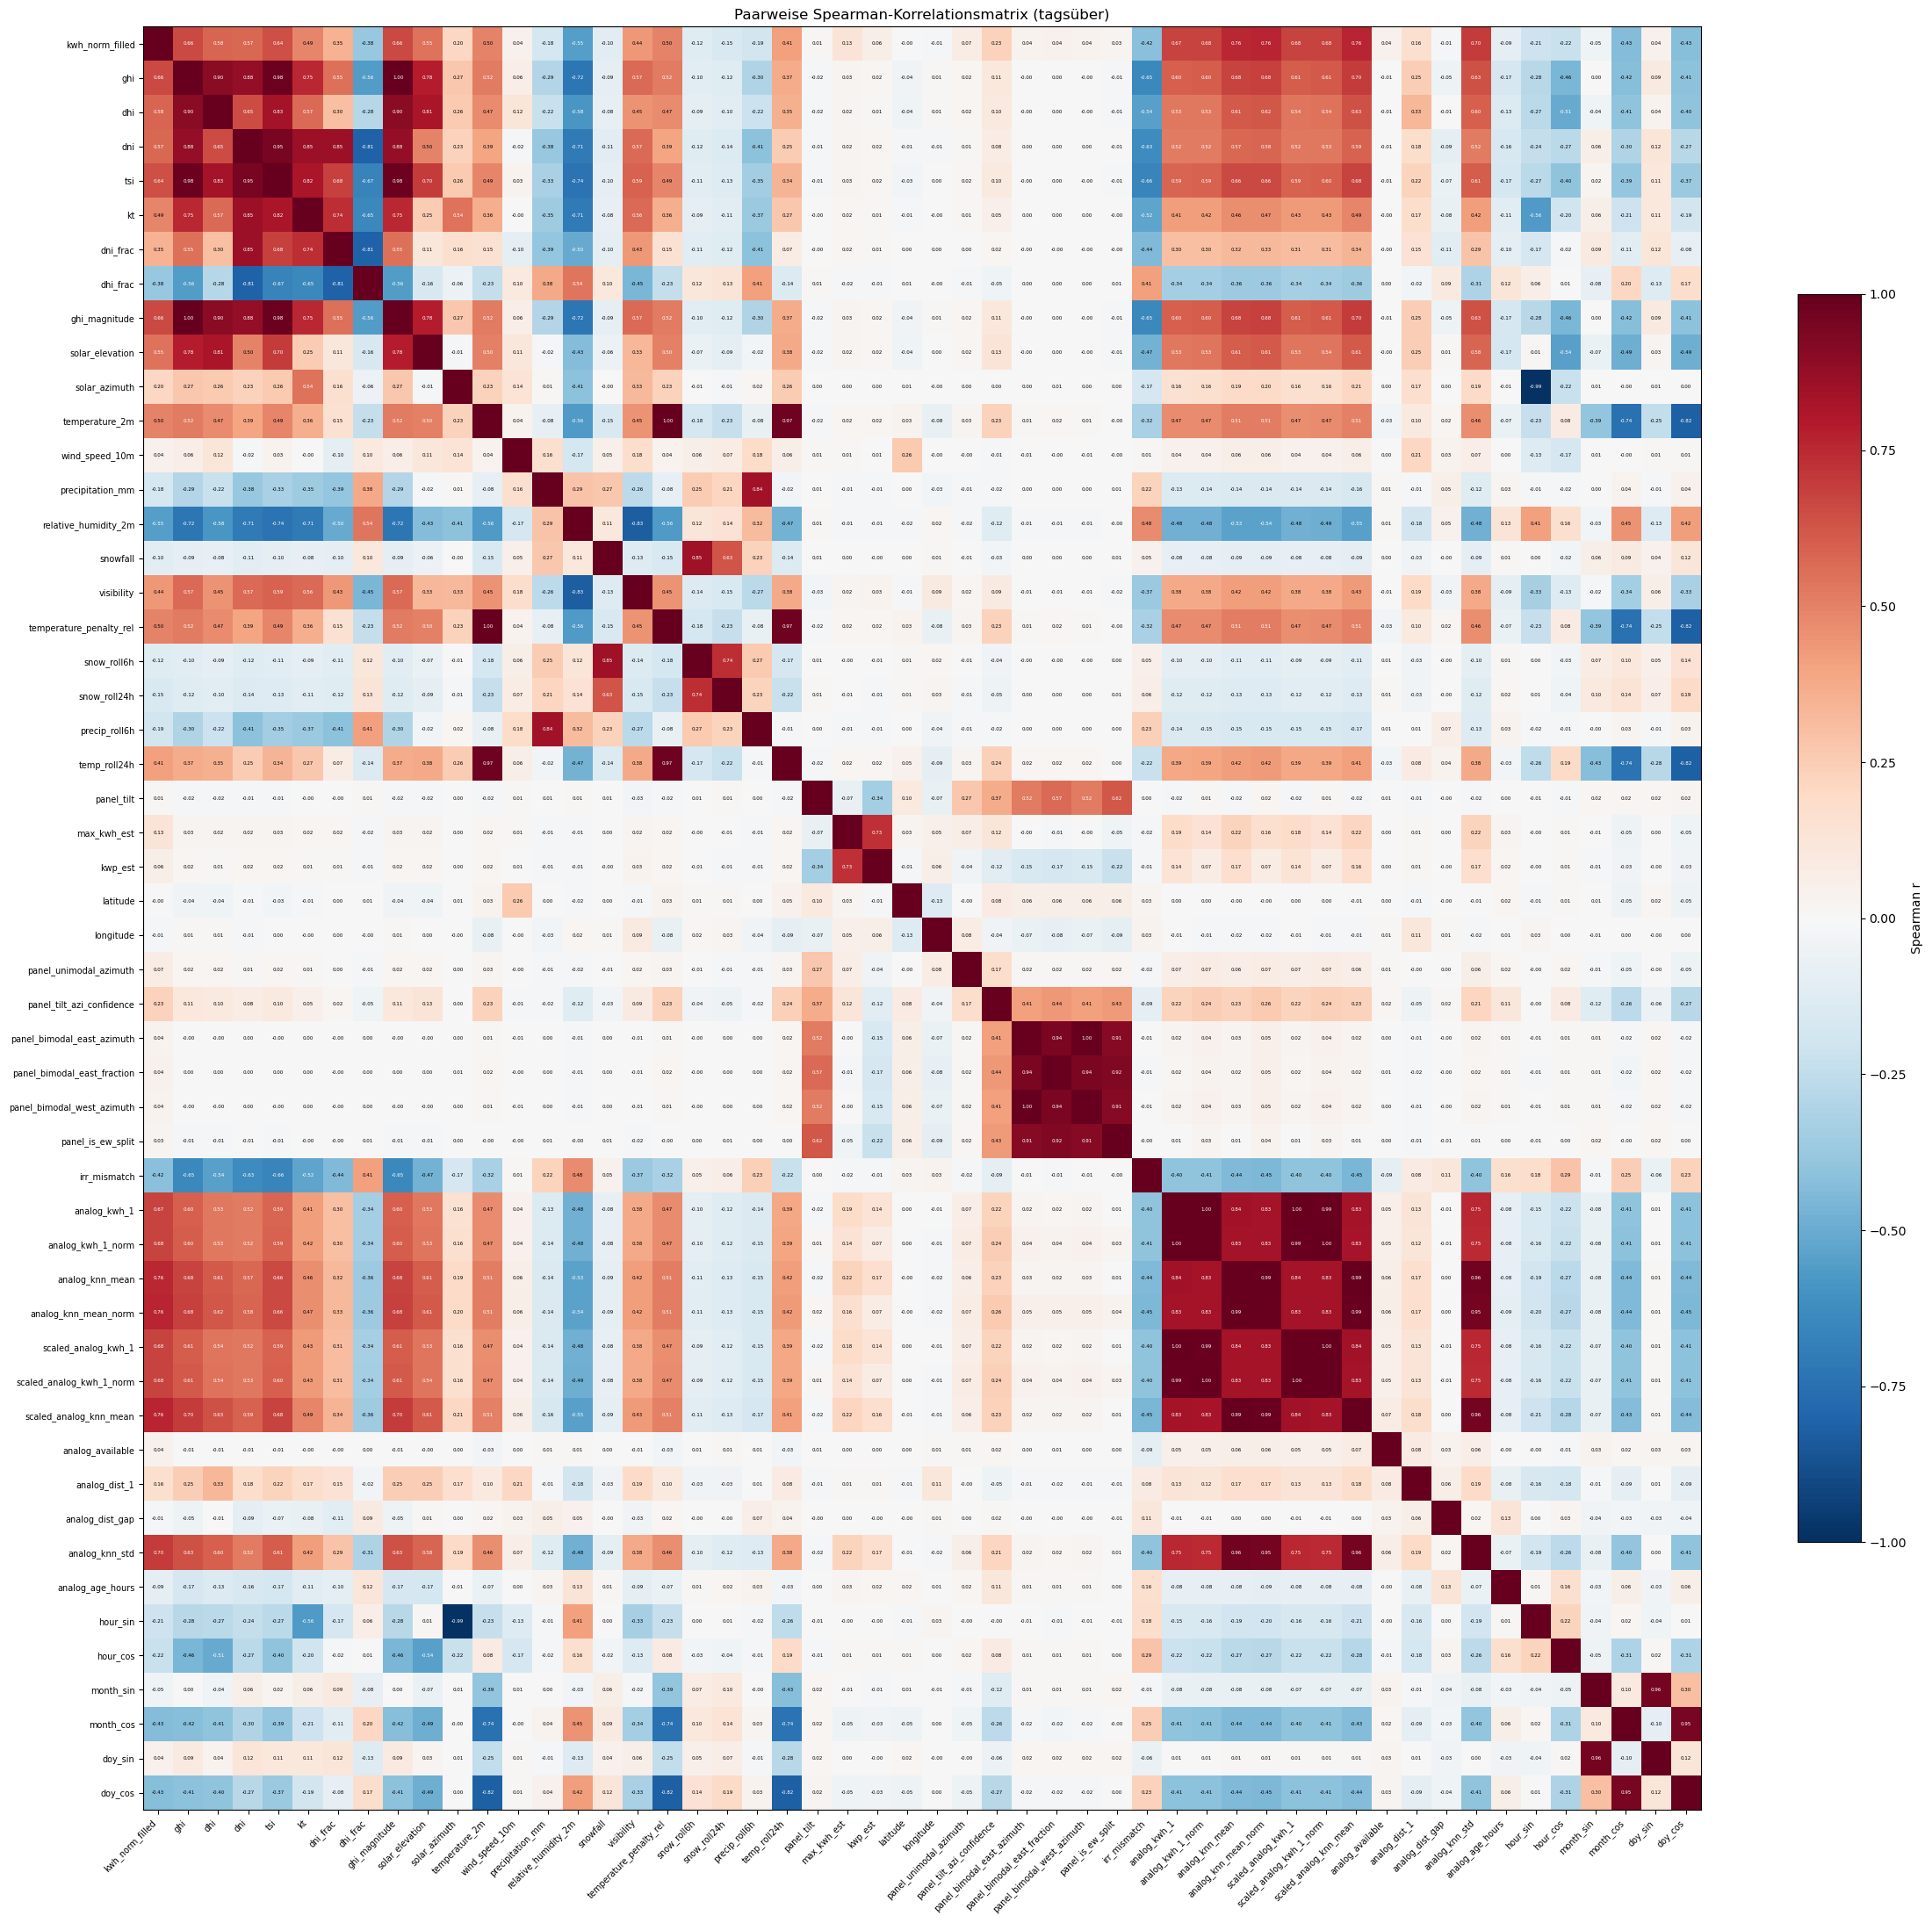


Top 15 stärkste Korrelationspaare (|r|):
  ghi                                 ↔  ghi_magnitude                   r = +1.000
  temperature_2m                      ↔  temperature_penalty_rel         r = +1.000
  panel_bimodal_east_azimuth          ↔  panel_bimodal_west_azimuth      r = +1.000
  analog_kwh_1_norm                   ↔  scaled_analog_kwh_1_norm        r = +0.997
  analog_kwh_1                        ↔  scaled_analog_kwh_1             r = +0.997
  scaled_analog_kwh_1                 ↔  scaled_analog_kwh_1_norm        r = +0.996
  analog_kwh_1                        ↔  analog_kwh_1_norm               r = +0.995
  analog_knn_mean                     ↔  scaled_analog_knn_mean          r = +0.994
  analog_knn_mean                     ↔  analog_knn_mean_norm            r = +0.992
  analog_kwh_1                        ↔  scaled_analog_kwh_1_norm        r = +0.992
  analog_kwh_1_norm                   ↔  scaled_analog_kwh_1             r = +0.992
  solar_azimuth                   

0

In [10]:
from scipy.stats import rankdata

mat_present = [f for f in present if f != 'weather_regime']
print(f'Features in Matrix: {len(mat_present)}')

# Erst Index sampeln, dann nur die nötigen Spalten laden
_mask = df['_daylight'].to_numpy(dtype=bool)
day_idx = np.where(_mask)[0]
del _mask; gc.collect()

n_sample = min(50_000, len(day_idx))
sample_idx = np.sort(np.random.default_rng(42).choice(day_idx, n_sample, replace=False))
del day_idx; gc.collect()

# Nur gesampelte Zeilen + nötige Spalten
mat_sample = df.iloc[sample_idx][mat_present].dropna()
del sample_idx; gc.collect()
print(f'Sample: {len(mat_sample):,} Zeilen')

# Ränge in float64 — 50k Zeilen kein RAM-Problem
X = mat_sample.values.astype(np.float64)
del mat_sample; gc.collect()

for i in range(X.shape[1]):
    X[:, i] = rankdata(X[:, i])

X -= X.mean(axis=0)
X /= (X.std(axis=0) + 1e-8)

corr_vals = np.clip((X.T @ X) / (len(X) - 1), -1.0, 1.0).astype(np.float32)
spearman_matrix = pd.DataFrame(corr_vals, index=mat_present, columns=mat_present)
del X, corr_vals; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────
n = len(mat_present)
fig, ax = plt.subplots(figsize=(min(24, n * 0.5), min(22, n * 0.45)))
im = ax.imshow(spearman_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman r', shrink=0.7)
ax.set_xticks(range(n)); ax.set_xticklabels(mat_present, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(mat_present, fontsize=7)
for i in range(n):
    for j in range(n):
        val = float(spearman_matrix.values[i, j])
        if i != j:
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=4, color=color)
ax.set_title('Paarweise Spearman-Korrelationsmatrix (tagsüber)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '15b_corr_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
gc.collect()

# ── Top Korrelationspaare ─────────────────────────────────────────────
upper = spearman_matrix.where(np.triu(np.ones(spearman_matrix.shape), k=1).astype(bool))
top_corr = upper.stack().abs().sort_values(ascending=False).head(15)
print('\nTop 15 stärkste Korrelationspaare (|r|):')
for (f1, f2), _ in top_corr.items():
    val = spearman_matrix.loc[f1, f2]
    print(f'  {f1:35s} ↔  {f2:30s}  r = {val:+.3f}')
del spearman_matrix, upper, top_corr; gc.collect()

## 10c. Zeitliche & Lag-Korrelationsanalyse

**Zwei Fragen:**

1. **Lag-Korrelation** (Vorhersage-Relevanz): Wie stark korreliert Feature X(t) mit kwh(t + lag)?
   D.h. wie gut eignet sich ein Feature als Prädiktor für die Produktion in 15 Min, 1h, 2h, ... 36h?
   Je höher die Korrelation noch bei großem Lag, desto wertvoller für Langzeit-Forecasting.

2. **Monatliche Korrelation**: Verändert sich die Vorhersagekraft saisonal?
   (GHI im Winter vs. Sommer; Analog-Features im Winter wenn wenige klare Referenztage vorhanden)

Lag-Korrelationen (Spearman, Median über 100 Spots):
                            15m     1h     2h     4h     6h    12h    24h    36h
ghi                       0.683  0.619  0.488  0.172  0.028  0.300  0.166  0.168
kt                        0.460  0.346  0.227  0.089  0.088  0.204  0.130  0.076
solar_elevation           0.546  0.563  0.505  0.173 -0.070  0.296  0.133  0.202
analog_kwh_1              0.551  0.513  0.416  0.170  0.057  0.312  0.166  0.175
analog_kwh_1_norm         0.551  0.513  0.416  0.170  0.057  0.312  0.166  0.175
analog_knn_mean           0.680  0.615  0.476  0.189  0.053  0.347  0.202  0.199
scaled_analog_kwh_1_norm  0.555  0.514  0.419  0.169  0.056  0.307  0.164  0.171
temperature_2m            0.459  0.401  0.326  0.210  0.212  0.363  0.314  0.293
wind_speed_10m            0.040  0.007 -0.032 -0.127 -0.139 -0.015 -0.031 -0.051
precipitation_mm         -0.183 -0.177 -0.167 -0.147 -0.108 -0.058 -0.057 -0.043
irr_mismatch             -0.414 -0.384 -0.291 -0.110 -0.

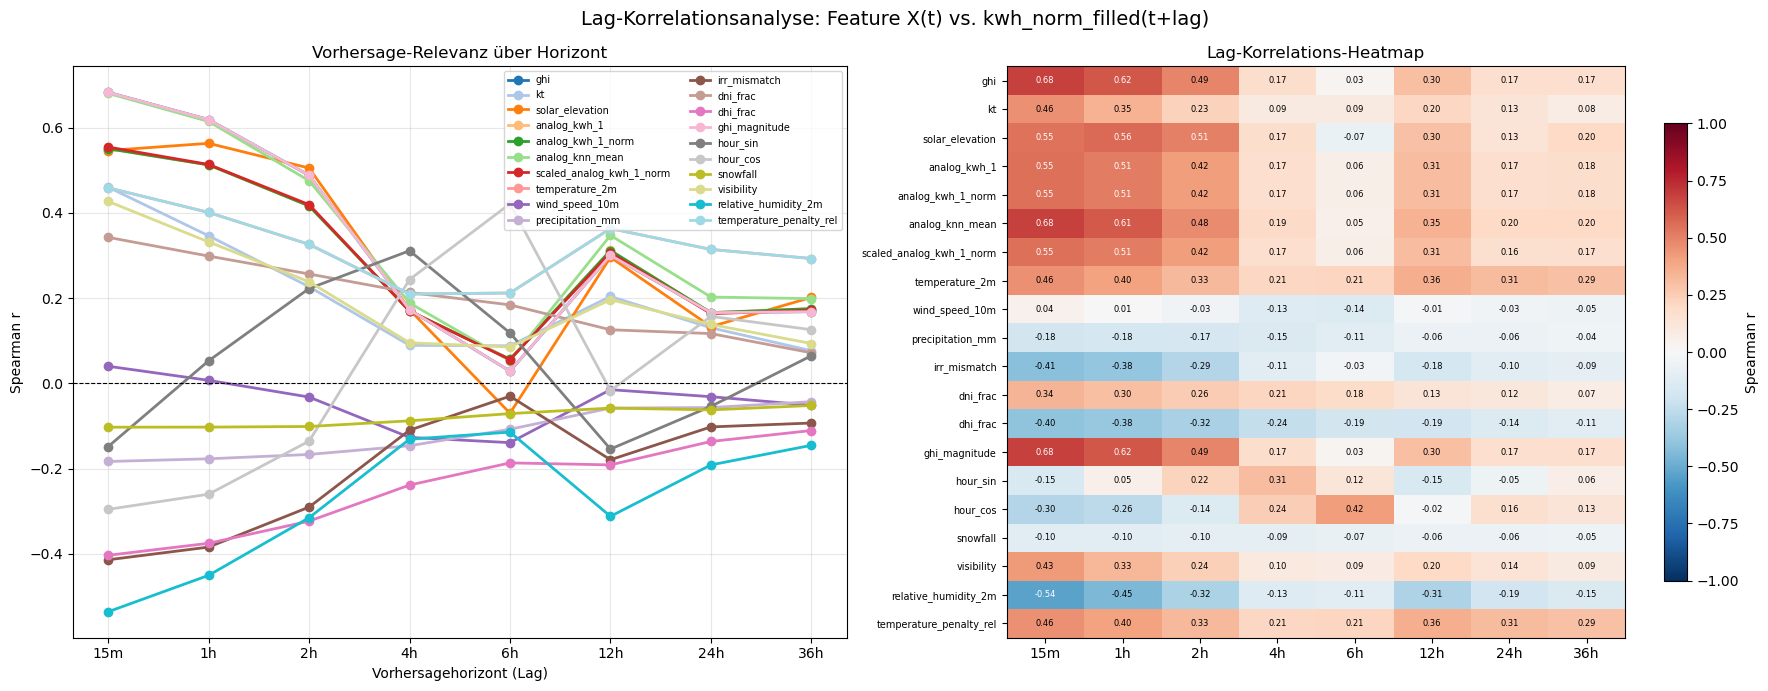

12635

In [9]:
C_now = set(df.columns)

LAGS_SLOTS  = [1, 4, 8, 16, 24, 48, 96, 144]
LAGS_LABELS = ['15m','1h','2h','4h','6h','12h','24h','36h']

LAG_FEATS = ['ghi', 'kt', 'solar_elevation',
             'analog_kwh_1', 'analog_kwh_1_norm',
             'analog_knn_mean', 'scaled_analog_kwh_1_norm',
             'temperature_2m', 'wind_speed_10m', 'precipitation_mm',
             'irr_mismatch', 'dni_frac', 'dhi_frac', 'ghi_magnitude',
             'hour_sin', 'hour_cos']
for f in ['snowfall', 'visibility', 'relative_humidity_2m', 'temperature_penalty_rel']:
    if f in C_now: LAG_FEATS.append(f)
LAG_FEATS = [f for f in LAG_FEATS if f in C_now]

sample_spots = np.random.default_rng(42).choice(
    df['spot_uuid'].unique(), size=min(100, df['spot_uuid'].nunique()), replace=False)

lag_corr_results = {feat: [] for feat in LAG_FEATS}

for spot in sample_spots:
    sub = df[df['spot_uuid'] == spot].sort_values('ts').reset_index(drop=True)
    sub = sub[sub['solar_elevation'] > 0]
    if len(sub) < 200:
        continue
    for feat in LAG_FEATS:
        feat_series = sub[feat].values
        kwh_series  = sub['kwh_norm_filled'].values
        row = []
        for lag in LAGS_SLOTS:
            x = feat_series[:-lag]
            y = kwh_series[lag:]
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() > 50:
                r, _ = spearmanr(x[mask], y[mask])
                row.append(r)
            else:
                row.append(np.nan)
        lag_corr_results[feat].append(row)

lag_corr_median = {feat: np.nanmedian(np.array(lag_corr_results[feat]), axis=0)
                   for feat in LAG_FEATS}
del lag_corr_results; gc.collect()

lag_df = pd.DataFrame(lag_corr_median, index=LAGS_LABELS).T
del lag_corr_median; gc.collect()

print('Lag-Korrelationen (Spearman, Median über 100 Spots):')
print(lag_df.round(3).to_string())

# ── Plot Lag ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Lag-Korrelationsanalyse: Feature X(t) vs. kwh_norm_filled(t+lag)', fontsize=14)

cmap_lag = plt.cm.get_cmap('tab20', len(LAG_FEATS))
ax = axes[0]
for i, feat in enumerate(LAG_FEATS):
    ax.plot(LAGS_LABELS, lag_df.loc[feat].values, marker='o', lw=2,
            label=feat, color=cmap_lag(i))
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Vorhersagehorizont (Lag)'); ax.set_ylabel('Spearman r')
ax.set_title('Vorhersage-Relevanz über Horizont')
ax.legend(fontsize=7, ncol=2, loc='upper right'); ax.grid(True, alpha=0.3)

ax = axes[1]
im = ax.imshow(lag_df.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman r', shrink=0.8)
for i in range(len(lag_df.index)):
    for j in range(len(LAGS_LABELS)):
        val = lag_df.values[i, j]
        if np.isfinite(val):
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color=color)
ax.set_xticks(range(len(LAGS_LABELS))); ax.set_xticklabels(LAGS_LABELS)
ax.set_yticks(range(len(lag_df.index))); ax.set_yticklabels(lag_df.index, fontsize=7)
ax.set_title('Lag-Korrelations-Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '14_lag_correlations.png', dpi=100, bbox_inches='tight')
plt.show()
del lag_df; gc.collect()

## 11. Typische Tagesverläufe (repräsentative Spots)

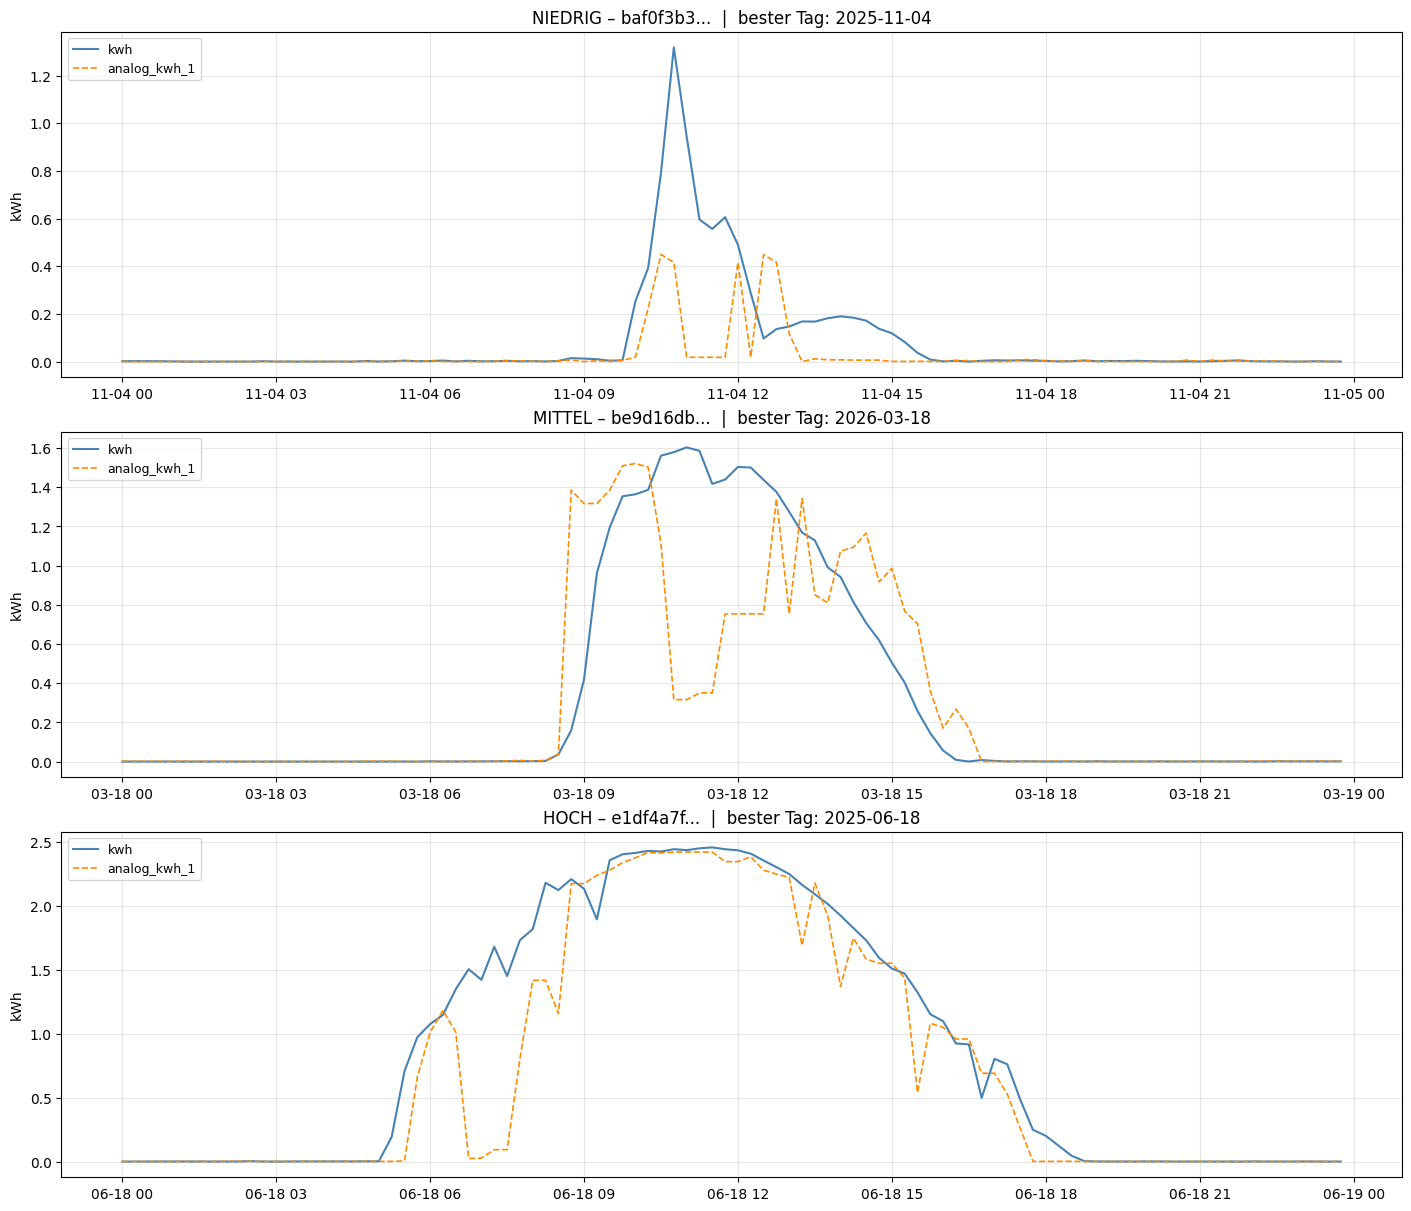

In [ ]:
# Caps nur mit nötigen Spalten
caps = (df.loc[df['_daylight'], ['spot_uuid', 'kwh']]
          .groupby('spot_uuid', observed=True)['kwh']
          .quantile(0.99).dropna().sort_values())
n   = len(caps)
rep = {
    'niedrig': caps.index[max(0, int(n*0.1))],
    'mittel':  caps.index[n//2],
    'hoch':    caps.index[min(n-1, int(n*0.9))],
}
del caps; gc.collect()

# Besten Tag pro Spot vorberechnen — einmal statt 3× filtern
spot_list  = list(rep.values())
df_spots   = df.loc[df['spot_uuid'].isin(spot_list), ['spot_uuid', 'ts', '_date', 'kwh', 'analog_kwh_1'] 
                    if 'analog_kwh_1' in df.columns else ['spot_uuid', 'ts', '_date', 'kwh']]

best_days  = (df_spots.groupby(['spot_uuid', '_date'], observed=True)['kwh']
                       .sum()
                       .reset_index()
                       .sort_values('kwh', ascending=False)
                       .drop_duplicates('spot_uuid')
                       .set_index('spot_uuid')['_date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)
for ax, (label, spot) in zip(axes, rep.items()):
    day = best_days[spot]
    sub = df_spots[(df_spots['spot_uuid'] == spot) & (df_spots['_date'] == day)].sort_values('ts')
    ax.plot(sub['ts'], sub['kwh'], color='steelblue', lw=1.5, label='kwh')
    if 'analog_kwh_1' in sub.columns:
        ax.plot(sub['ts'], sub['analog_kwh_1'], color='darkorange', lw=1.2, ls='--', label='analog_kwh_1')
    ax.set_title(f'{label.upper()} – {spot[:8]}...  |  bester Tag: {day}')
    ax.set_ylabel('kWh')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR / '14_typical_day.png', dpi=100)
plt.show()
del df_spots, best_days; gc.collect()

## 12. Zusammenfassung

In [ ]:
print('=' * 65)
print('ZUSAMMENFASSUNG – PV Explorative Datenanalyse')
print('=' * 65)
print(f'Datenbasis:     {DATA_PATH.name}')
print(f'Zeitraum:       {ts_min.date()} → {ts_max.date()}')
print(f'Spots:          {n_spots}')
print(f'Zeilen:         {len(df):,}')
print(f'Features:       52 (ohne kwh_norm / kwh_norm_filled)')
print()
print('Highlights:')
print(f'  • Panel-Tilt geschätzt:        {df["panel_tilt"].notna().sum() if "panel_tilt" in df.columns else "n/a"} Zeilen')
print(f'  • Analog-Features vorhanden:   {"Ja" if "analog_kwh_1" in df.columns else "Nein"}')
print(f'  • kwh_norm NaN (Ausreißer):    {df["kwh_norm"].isna().sum():,} ({df["kwh_norm"].isna().mean()*100:.1f}%)')
print(f'  • kwh_norm_filled:             {"Ja" if "kwh_norm_filled" in df.columns else "Nein"}')
per_spot_miss_pct = df[df['_daylight']].groupby('spot_uuid')['kwh_norm'].apply(lambda x: x.isna().mean() * 100)
print(f'  • Spots mit <10% NaN tagsüber: {(per_spot_miss_pct < 10).sum()} / {len(per_spot_miss_pct)}')
print(f'  • Reports gespeichert in:      {OUTPUT_DIR}')

ZUSAMMENFASSUNG – PV Explorative Datenanalyse
Datenbasis:     data_final.parquet
Zeitraum:       2024-07-09 → 2026-03-27
Spots:          3016
Zeilen:         67,917,827
Features:       52 (ohne kwh_norm / kwh_norm_filled)

Highlights:
  • Panel-Tilt geschätzt:        67917827 Zeilen
  • Analog-Features vorhanden:   Ja


  • kwh_norm NaN (Ausreißer):    3,297,136 (4.9%)
  • kwh_norm_filled:             Ja


  • Spots mit <10% NaN tagsüber: 1475 / 3016
  • Reports gespeichert in:      ../reports/eda_spt
